In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Step 1: Data Loading and Initial Exploration

In [2]:
customers=pd.read_csv("customers.csv")
print(customers.head())
print(customers.shape)
print(customers.info())
#print("Duplicates",customers.duplicated().sum)
print(customers["customer_id"].nunique()) #primary key
print(customers.shape[0])
print(customers["customer_unique_id"].nunique())
print(customers.shape[0])


                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
(99441, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non

In [3]:
orders=pd.read_csv("orders.csv")
print(orders.head())
print(orders.shape)
print(orders.info())
print(orders.isnull().sum())
#print("Duplicates",orders.duplicated().sum) 
print(orders["customer_id"].nunique())#foreign key
print(orders.shape[0])
print(orders["order_id"].nunique()) #primary key
print(orders["customer_id"].isin(customers["customer_id"]).all())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [4]:
order_items = pd.read_csv("order_item.csv")
print(order_items.head())
print(order_items.shape)
print(order_items.isnull().sum())
print(order_items["order_id"].nunique()) #foreign key
print(order_items["order_item_id"].nunique()) #primary key
print(order_items["product_id"].nunique()) #foreign key
print(order_items["seller_id"].nunique()) #foreign key
print(order_items[["order_id", "order_item_id"]].drop_duplicates().shape[0]) #composite primary key
print(order_items.shape[0])


                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

In [5]:
payments = pd.read_csv("payments.csv")
print(payments.head())
print(payments.shape)
print(payments.isnull().sum())
print(payments["order_id"].nunique()) #foreign key
print(payments["payment_type"].nunique())
print(payments["payment_type"].value_counts())
print(payments['payment_sequential'].nunique()) #primary key
print(payments[["order_id", "payment_sequential"]].drop_duplicates().shape[0]) #composite primary key
print(payments.shape[0])


                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  
(103886, 5)
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
99440
5
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64
29
103886
103886


In [6]:
reviews = pd.read_csv("reviews.csv")
print(reviews.head())
print(reviews.shape)
print(reviews.isnull().sum())
print(reviews["review_id"].nunique()) #primary key
print(reviews["order_id"].nunique()) #foreign key
print(reviews["review_score"].nunique())
print(reviews["review_score"].value_counts())

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

In [7]:
products = pd.read_csv("products.csv")
print(products.head())
print(products.shape)
print(products.isnull().sum())
print(products["product_id"].nunique()) #primary key
print(products["product_category_name"].nunique()) #foreign key to categpory_name_translation table
#print(products["product_category_name"].value_counts())



                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [8]:
sellers = pd.read_csv("sellers.csv")
print(sellers.head())
print(sellers.shape)
print(sellers.isnull().sum())
print(sellers["seller_id"].nunique()) #primary key
print(sellers["seller_zip_code_prefix"].nunique())
print(sellers["seller_city"].nunique())
print(sellers["seller_state"].nunique())



                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP  
(3095, 4)
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
3095
2246
611
23


In [9]:
category_name_translation = pd.read_csv("category_translation.csv")
print(category_name_translation.head())
print(category_name_translation.shape)
print(category_name_translation.isnull().sum())
print(category_name_translation["product_category_name"].nunique()) #primary key
print(category_name_translation["product_category_name_english"].nunique()) #foreign key to products table

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
(71, 2)
product_category_name            0
product_category_name_english    0
dtype: int64
71
71


Step 2: Data Cleaning and Preprocessing

•	Handle missing values appropriately 

In [10]:
#Check for missing values in each dataset
# print("Customers:\n",customers.isnull().sum())
# print("Orders:\n",orders.isnull().sum())
# print("Order Items:\n",order_items.isnull().sum())
# print("Payments:\n",payments.isnull().sum())
# print("Reviews:\n",reviews.isnull().sum())
# print("Products:\n",products.isnull().sum())
# print("Sellers:\n",sellers.isnull().sum())
# print("Category Name Translation:\n",category_name_translation.isnull().sum())
tables = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_name_translation": category_name_translation
}
for name, df in tables.items():
    null_count = df.isnull().sum()
    null_count = null_count[null_count > 0]
    print(f"\n {name}:")
    if null_count.empty:
        print("  No missing values")
    else:
        print(null_count)


 orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

 customers:
  No missing values

 order_items:
  No missing values

 payments:
  No missing values

 reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64

 products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

 sellers:
  No missing values

 category_name_translation:
  No missing values


In [11]:
# Check order_status distribution first
print(orders["order_status"].value_counts())
orders = orders[orders["order_status"] == "delivered"]
print(orders.shape)
print(orders.isnull().sum())


delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64
(96478, 8)
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64


In [12]:
# Drop remaining null rows in orders
orders = orders.dropna(subset=["order_approved_at","order_delivered_carrier_date", "order_delivered_customer_date"])
# Verify
print(orders.shape)
print(orders.isnull().sum())

(96455, 8)
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


In [13]:
# First check review_score nulls
print(reviews.isnull().sum())
print(reviews.shape)
# Also check
print(reviews["review_score"].value_counts())

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
(99224, 7)
5    57328
4    19142
1    11424
3     8179
2     3151
Name: review_score, dtype: int64


In [14]:
reviews["review_comment_title"].fillna("No Title", inplace=True)
reviews["review_comment_message"].fillna("No Comment", inplace=True)
print(reviews.isnull().sum())
print(reviews.shape)

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64
(99224, 7)


In [15]:
print(products.shape)
# Checking if same 610 rows are null across all columns
null_mask = products["product_category_name"].isnull()
print(products[null_mask].tail())

(32951, 9)
                             product_id product_category_name  \
32515  b0a0c5dd78e644373b199380612c350a                   NaN   
32589  10dbe0fbaa2c505123c17fdc34a63c56                   NaN   
32616  bd2ada37b58ae94cc838b9c0569fecd8                   NaN   
32772  fa51e914046aab32764c41356b9d4ea4                   NaN   
32852  c4ceee876c82b8328e9c293fa0e1989b                   NaN   

       product_name_lenght  product_description_lenght  product_photos_qty  \
32515                  NaN                         NaN                 NaN   
32589                  NaN                         NaN                 NaN   
32616                  NaN                         NaN                 NaN   
32772                  NaN                         NaN                 NaN   
32852                  NaN                         NaN                 NaN   

       product_weight_g  product_length_cm  product_height_cm  \
32515            1800.0               30.0               20.0   

In [16]:
# Fill category name with Unknown
products["product_category_name"].fillna("Unknown", inplace=True)
# Fill numeric columns with median
numeric_cols = ["product_name_lenght", 
                "product_description_lenght",
                "product_photos_qty",
                "product_weight_g",
                "product_length_cm", 
                "product_height_cm", 
                "product_width_cm"]

for col in numeric_cols:
    products[col].fillna(products[col].median(), inplace=True)
print(products.isnull().sum())
print(products.shape)

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64
(32951, 9)


•	Remove duplicate records 

In [17]:
tables = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_name_translation": category_name_translation
}
for name, df in tables.items():
    print(f"{name} duplicates: {df.duplicated().sum()}")

orders duplicates: 0
customers duplicates: 0
order_items duplicates: 0
payments duplicates: 0
reviews duplicates: 0
products duplicates: 0
sellers duplicates: 0
category_name_translation duplicates: 0


•	Convert date columns to datetime format 

In [18]:
# Convert date columns to datetime for orders
date_cols_orders = ["order_purchase_timestamp",
                    "order_approved_at",
                    "order_delivered_carrier_date",
                    "order_delivered_customer_date",
                    "order_estimated_delivery_date"]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col])
# for order_items
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])
# reviews
date_cols_reviews = ["review_creation_date", 
                     "review_answer_timestamp"]

for col in date_cols_reviews:
    reviews[col] = pd.to_datetime(reviews[col])
# Check dtypes
print("orders dtypes:\n", orders.dtypes)
print("\norder_items dtypes:\n", order_items.dtypes)
print("\nreviews dtypes:\n", reviews.dtypes)

orders dtypes:
 order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

order_items dtypes:
 order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

reviews dtypes:
 review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_

•	Validate data types and ranges 

In [19]:
# 1. price and freight should be positive
print("Negative prices:", (order_items["price"] <= 0).sum())
print("Negative freight:", (order_items["freight_value"] <= 0).sum())
# 2. review_score should be between 1-5
print("Invalid review scores:", reviews[~reviews["review_score"].between(1, 5)].shape[0])
# 3. payment_value should be positive
print("Negative payments:", (payments["payment_value"] <= 0).sum())
# 4. products numeric ranges
print("Negative weight:", (products["product_weight_g"] <= 0).sum())
print("Negative dimensions:", ((products["product_length_cm"] <= 0) |(products["product_height_cm"] <= 0) |(products["product_width_cm"] <= 0)).sum())

Negative prices: 0
Negative freight: 383
Invalid review scores: 0
Negative payments: 9
Negative weight: 4
Negative dimensions: 0


In [20]:
# Check what these negative freight rows look like
print(order_items[order_items["freight_value"] <= 0][["order_id", "price", "freight_value"]])

                                order_id  price  freight_value
114     00404fa7a687c8c44ca69d42695aae73   99.9            0.0
258     00a870c6c06346e85335524935c600c0   69.9            0.0
483     011c899816ea29773525bd3322dbb6aa   99.9            0.0
508     012b3f6ab7776a8ab3443a4ad7bef2e6   53.9            0.0
509     012b3f6ab7776a8ab3443a4ad7bef2e6   53.9            0.0
...                                  ...    ...            ...
111094  fc698f330ec7fb74859071cc6cb29772   53.9            0.0
111497  fd4907109f6bac23f07064af84bec02d  219.0            0.0
111649  fd95e4b85ebbb81853d4a6be3d61432b  106.9            0.0
112182  fee19a0dc7358b6962a611cecf6a37b4  195.0            0.0
112607  ffe73fc1d73e03fdb50e63903ddfe882  112.9            0.0

[383 rows x 3 columns]


In [21]:
print("Negative payments:", (payments[payments["payment_value"] <= 0][["order_id", "payment_value"]]))

Negative payments:                                 order_id  payment_value
19922   8bcbe01d44d147f901cd3192671144db            0.0
36822   fa65dad1b0e818e3ccc5cb0e39231352            0.0
43744   6ccb433e00daae1283ccc956189c82ae            0.0
51280   4637ca194b6387e2d538dc89b124b0ee            0.0
57411   00b1cb0320190ca0daa2c88b35206009            0.0
62674   45ed6e85398a87c253db47c2d9f48216            0.0
77885   fa65dad1b0e818e3ccc5cb0e39231352            0.0
94427   c8c528189310eaa44a745b8d9d26908b            0.0
100766  b23878b3e8eb4d25a158f57d96331b18            0.0


In [22]:
# Check payment_type for these 0 value rows
print(payments[payments["payment_value"] <= 0][["order_id", "payment_type", "payment_value"]])

                                order_id payment_type  payment_value
19922   8bcbe01d44d147f901cd3192671144db      voucher            0.0
36822   fa65dad1b0e818e3ccc5cb0e39231352      voucher            0.0
43744   6ccb433e00daae1283ccc956189c82ae      voucher            0.0
51280   4637ca194b6387e2d538dc89b124b0ee  not_defined            0.0
57411   00b1cb0320190ca0daa2c88b35206009  not_defined            0.0
62674   45ed6e85398a87c253db47c2d9f48216      voucher            0.0
77885   fa65dad1b0e818e3ccc5cb0e39231352      voucher            0.0
94427   c8c528189310eaa44a745b8d9d26908b  not_defined            0.0
100766  b23878b3e8eb4d25a158f57d96331b18      voucher            0.0


In [23]:
# Drop only not_defined with 0 payment value
payments = payments[~((payments["payment_type"] == "not_defined") &  (payments["payment_value"] == 0.0))]
print(payments.shape)
print(payments["payment_type"].value_counts())

(103883, 5)
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
Name: payment_type, dtype: int64


In [24]:
print("Negative weight:", (products[products["product_weight_g"] <= 0][["product_id", "product_weight_g"]]))

Negative weight:                              product_id  product_weight_g
9769   81781c0fed9fe1ad6e8c81fca1e1cb08               0.0
13683  8038040ee2a71048d4bdbbdc985b69ab               0.0
14997  36ba42dd187055e1fbe943b2d11430ca               0.0
32079  e673e90efa65a5409ff4196c038bb5af               0.0


In [25]:
# Replace 0 weight with median
median_weight = products[products["product_weight_g"] > 0]["product_weight_g"].median()
products.loc[products["product_weight_g"] == 0, "product_weight_g"] = median_weight
print("Zero weights remaining:", (products["product_weight_g"] == 0).sum())
print("Median weight used:", median_weight)

Zero weights remaining: 0
Median weight used: 700.0


•	Standardize column names if required 

In [26]:
# All column check
for name, df in tables.items():
    print(f"\n{name}: {list(df.columns)}")


orders: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

customers: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

order_items: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

payments: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

reviews: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

products: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

sellers: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

category_name_transla

In [27]:
products.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
}, inplace=True)
print(products.columns.tolist())

['product_id', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


Step 3: Data Integration (Critical Component)

In [28]:
# Step 1 — orders + customers
master = orders.merge(customers, on="customer_id", how="left")
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [29]:
print(orders.shape)
print(customers.shape)
print(master.shape)

(96455, 8)
(99441, 5)
(96455, 12)


In [30]:
# Step 2 — master + order_items
master = master.merge(order_items, on="order_id", how="left")
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [31]:
print(order_items.shape)
print(master.shape)

(112650, 7)
(110173, 18)


In [32]:
# Step 3 — master + products
master = master.merge(products, on="product_id", how="left")
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [33]:
print(products.shape)
print(master.shape)

(32951, 9)
(110173, 26)


In [34]:
# Step 4 — master + category_name_translation
master = master.merge(category_name_translation, on="product_category_name", how="left")
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [35]:
print(category_name_translation.shape)
print(master.shape)

(71, 2)
(110173, 27)


In [36]:
# Step 5 — master + payments
master = master.merge(payments, on="order_id", how="left")
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,perfumery,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,auto,1.0,credit_card,3.0,179.12


In [37]:
print(payments.shape)
print(master.shape)

(103883, 5)
(115014, 31)


In [38]:
# Step 6 — master + reviews
master = master.merge(reviews, on="order_id", how="left")
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 19:07:58


In [39]:
print(reviews.shape)
print(master.shape)

(99224, 7)
(115699, 37)


In [40]:
master=master.merge(sellers, on="seller_id", how="left")
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP


In [41]:
print(sellers.shape)
print(master.shape)
print(master.columns.tolist())

(3095, 4)
(115699, 40)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


In [42]:
master.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP


In [43]:
print("Shape:\n",master.shape)
print("Null Values:\n", master.isnull().sum()[master.isnull().sum() > 0])
print("Data Types:\n", master.dtypes)

Shape:
 (115699, 40)
Null Values:
 product_category_name_english    1660
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
review_id                         861
review_score                      861
review_comment_title              861
review_comment_message            861
review_creation_date              861
review_answer_timestamp           861
dtype: int64
Data Types:
 order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            

In [44]:
master[master["product_category_name_english"].isnull()][["product_category_name_english", "product_category_name"]]
#print("Null Values:\n", master.isnull())


,product_category_name_english,product_category_name
126,NaN,Unknown
215,NaN,Unknown
268,NaN,Unknown
309,NaN,Unknown
381,NaN,Unknown
...,...,...
115265,NaN,Unknown
115437,NaN,Unknown
115444,NaN,Unknown
115450,NaN,Unknown


In [45]:
# See what Portuguese categories have no English translation
print(master[master["product_category_name_english"].isnull()]["product_category_name"].value_counts())

Unknown                                          1637
portateis_cozinha_e_preparadores_de_alimentos      14
pc_gamer                                            9
Name: product_category_name, dtype: int64


In [46]:
# Compare both columns side by side
print(category_name_translation.head(10)[["product_category_name", "product_category_name_english"]])

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
5           esporte_lazer                sports_leisure
6              perfumaria                     perfumery
7   utilidades_domesticas                    housewares
8               telefonia                     telephony
9      relogios_presentes                 watches_gifts


In [47]:
# Manual mapping for known Portuguese categories
master["product_category_name_english"] = master["product_category_name_english"].fillna(
    master["product_category_name"].map({
        "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_preparers",
        "pc_gamer": "pc_gamer",
        "Unknown": "Unknown"
    })
)
print(master["product_category_name_english"].isnull().sum())
print(master["product_category_name_english"].value_counts().tail(5))

0
portable_kitchen_food_preparers    14
cds_dvds_musicals                  14
pc_gamer                            9
fashion_childrens_clothes           7
security_and_services               2
Name: product_category_name_english, dtype: int64


In [48]:
# 1. payment nulls — only 3 rows, safe to drop
master = master.dropna(subset=["payment_value"])
# Check those 3 rows
print(master[master["payment_sequential"].isnull()][["order_id", "payment_value",  "payment_type", "payment_sequential"]])

Empty DataFrame
Columns: [order_id, payment_value, payment_type, payment_sequential]
Index: []


In [49]:
print("Null Values:\n", master.isnull().sum()[master.isnull().sum() > 0])

Null Values:
 review_id                  861
review_score               861
review_comment_title       861
review_comment_message     861
review_creation_date       861
review_answer_timestamp    861
dtype: int64


In [50]:
# review nulls — fill with neutral values
master["review_score"].fillna(0, inplace=True)
master["review_id"].fillna("No Review", inplace=True)
master["review_comment_title"].fillna("No Title", inplace=True)
master["review_comment_message"].fillna("No Comment", inplace=True)
master["review_creation_date"].fillna(pd.NaT, inplace=True)
master["review_answer_timestamp"].fillna(pd.NaT, inplace=True)

In [51]:
print("Shape:", master.shape)
print("Remaining nulls:\n", master.isnull().sum()[master.isnull().sum() > 0])

Shape: (115696, 40)
Remaining nulls:
 review_creation_date       861
review_answer_timestamp    861
dtype: int64


________________________________________
Step 4: Feature Engineering
________________________________________

In [52]:
#•	Total order value (aggregated from order_items or payments) 
# Order level — sum all payment_value per order
order_total = master.groupby("order_id")["payment_value"].sum().reset_index()
order_total.rename(columns={"payment_value": "total_order_value"}, inplace=True)
master = master.merge(order_total, on="order_id", how="left")
print(master[["order_id", "payment_value", "total_order_value"]].head(10))
print(master["total_order_value"].describe())

                           order_id  payment_value  total_order_value
0  e481f51cbdc54678b7cc49136f2d6af7          18.12              38.71
1  e481f51cbdc54678b7cc49136f2d6af7           2.00              38.71
2  e481f51cbdc54678b7cc49136f2d6af7          18.59              38.71
3  53cdb2fc8bc7dce0b6741e2150273451         141.46             141.46
4  47770eb9100c2d0c44946d9cf07ec65d         179.12             179.12
5  949d5b44dbf5de918fe9c16f97b45f8a          72.20              72.20
6  ad21c59c0840e6cb83a9ceb5573f8159          28.62              28.62
7  a4591c265e18cb1dcee52889e2d8acc3         175.26             175.26
8  6514b8ad8028c9f2cc2374ded245783f          75.16              75.16
9  76c6e866289321a7c93b82b54852dc33          35.95              35.95
count    115696.000000
mean        355.401596
std        1605.713262
min           9.590000
25%          67.830000
50%         126.820000
75%         257.930000
max      109312.640000
Name: total_order_value, dtype: float64


In [53]:
#Check actual dates for row 0
print(master[["order_purchase_timestamp",
              "order_estimated_delivery_date", 
              "order_delivered_customer_date"]].head(1))

  order_purchase_timestamp order_estimated_delivery_date  \
0      2017-10-02 10:56:33                    2017-10-18   

  order_delivered_customer_date  
0           2017-10-10 21:25:13  


In [54]:
#•	Delivery time (order purchase to delivery date) 
# Actual delivery time
master["delivery_time_days"] = (
    master["order_delivered_customer_date"] - 
    master["order_purchase_timestamp"]
).dt.days
#Estimated delivery time
master["estimated_delivery_days"] = (
    master["order_estimated_delivery_date"] - 
    master["order_purchase_timestamp"]
).dt.days
#Delivery delay (positive = late, negative = early)
master["delivery_delay_days"] = (
    master["order_delivered_customer_date"] - 
    master["order_estimated_delivery_date"]
).dt.total_seconds() / 86400 # convert to days
# Round to 1 decimal for clarity
master["delivery_delay_days"] = master["delivery_delay_days"].round(1) #These can be positive or negative depending on whether delivery was late or early
print(master[["delivery_time_days", 
              "estimated_delivery_days", 
              "delivery_delay_days"]].head())
print(master[["delivery_time_days", 
              "estimated_delivery_days", 
              "delivery_delay_days"]].describe())
print("Negative delivery times:", (master["delivery_time_days"] < 0).sum()) # Check for any negative delivery times which would indicate data issues
print("Negative delivery delays:", (master["estimated_delivery_days"] < 0).sum()) # Check for any negative delivery delays which would indicate data issues


   delivery_time_days  estimated_delivery_days  delivery_delay_days
0                   8                       15                 -7.1
1                   8                       15                 -7.1
2                   8                       15                 -7.1
3                  13                       19                 -5.4
4                   9                       26                -17.2
       delivery_time_days  estimated_delivery_days  delivery_delay_days
count       115696.000000            115696.000000        115696.000000
mean            12.020718                23.472791           -11.350874
std              9.452222                 8.814139            10.160982
min              0.000000                 2.000000          -146.000000
25%              6.000000                18.000000           -16.300000
50%             10.000000                23.000000           -12.100000
75%             15.000000                28.000000            -6.500000
max            2

In [55]:

#•	Number of items per order -Count items per order
items_per_order = master.groupby("order_id")["order_item_id"].count().reset_index()
items_per_order.rename(columns={"order_item_id": "items_per_order"}, inplace=True)
# Merge back to master
master = master.merge(items_per_order, on="order_id", how="left")
print(master["items_per_order"].describe())
print("\nValue counts:\n", master["items_per_order"].value_counts().head(3))

count    115696.000000
mean          1.667992
std           2.379561
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          63.000000
Name: items_per_order, dtype: float64

Value counts:
 1    83782
2    19260
3     4605
Name: items_per_order, dtype: int64


In [56]:
#•	Customer purchase frequency 
#  Count orders per customer
purchase_frequency = master.groupby("customer_unique_id")["order_id"].nunique().reset_index()
purchase_frequency.rename(columns={"order_id": "purchase_frequency"}, inplace=True)
# Merge back to master
master = master.merge(purchase_frequency, on="customer_unique_id", how="left")
print(master["purchase_frequency"].describe())
print("\nValue counts:\n", master["purchase_frequency"].value_counts().head(5))

count    115696.000000
mean          1.087669
std           0.392789
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          15.000000
Name: purchase_frequency, dtype: float64

Value counts:
 1    107487
2      7071
3       810
4       170
5        56
Name: purchase_frequency, dtype: int64


In [57]:
#•	Customer lifetime value (basic approximation) 
# Approximate CLV = total spent by customer
# Sum total spend per customer
clv = master.groupby("customer_unique_id")["total_order_value"].sum().reset_index()
clv.rename(columns={"total_order_value": "customer_lifetime_value"}, inplace=True)
master = master.merge(clv, on="customer_unique_id", how="left")
print(master["customer_lifetime_value"].describe())


count    115696.000000
mean       1848.815907
std       21382.769954
min          10.070000
25%          73.650000
50%         147.640000
75%         417.450000
max      905120.000000
Name: customer_lifetime_value, dtype: float64


In [58]:
#•	Average order value per customer 
avg_order_value = master.groupby("customer_unique_id")["total_order_value"].mean().reset_index()
avg_order_value.rename(columns={"total_order_value": "avg_order_value"}, inplace=True)
master = master.merge(avg_order_value, on="customer_unique_id", how="left")
print(master[["customer_unique_id", "total_order_value"]].head(3))
print(master["avg_order_value"].describe())

                 customer_unique_id  total_order_value
0  7c396fd4830fd04220f754e42b4e5bff              38.71
1  7c396fd4830fd04220f754e42b4e5bff              38.71
2  7c396fd4830fd04220f754e42b4e5bff              38.71
count    115696.000000
mean        355.401596
std        1596.992462
min           9.590000
25%          68.870000
50%         128.140000
75%         260.300000
max      109312.640000
Name: avg_order_value, dtype: float64


In [59]:
print("Present Master Shape:", master.shape)
print("Columns:", master.columns.tolist())

Present Master Shape: (115696, 48)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'total_order_value', 'delivery_time_days', 'estimated_delivery_days', 'delivery_delay_days', 'items_per_or

Step 5: Exploratory Data Analysis (EDA)

1.Customer Analysis

•	1A New vs repeat customers 

In [60]:
# Classify customers
master["customer_type"] = master["purchase_frequency"].apply(
    lambda x: "Repeat" if x > 1 else "New"
)
# Count unique customers per type
customer_type_counts = master.groupby("customer_type")["customer_unique_id"].nunique()
# Percentage
total_customers = customer_type_counts.sum()
customer_type_pct = (customer_type_counts / total_customers * 100).round(2)
print("Customer Type Count:\n", customer_type_counts)
print("\nCustomer Type Percentage:\n", customer_type_pct)

Customer Type Count:
 customer_type
New       90535
Repeat     2800
Name: customer_unique_id, dtype: int64

Customer Type Percentage:
 customer_type
New       97.0
Repeat     3.0
Name: customer_unique_id, dtype: float64


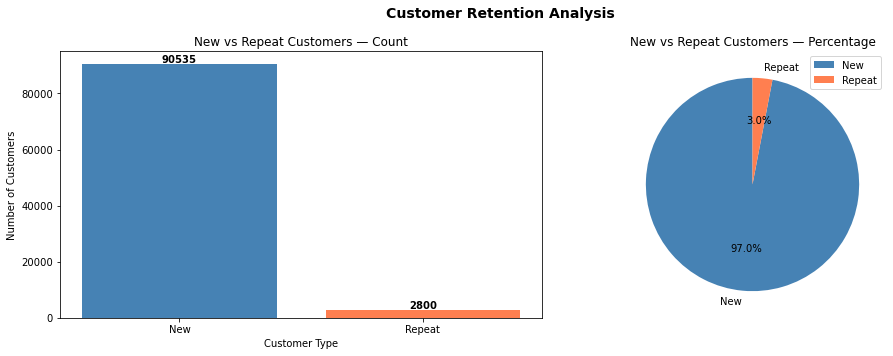

In [61]:
#Visualization of analysis of new vs repeat customers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Chart 1 — Bar chart
axes[0].bar(customer_type_counts.index, 
            customer_type_counts.values,
            color=["steelblue", "coral"])
axes[0].set_title("New vs Repeat Customers — Count")
axes[0].set_xlabel("Customer Type")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(customer_type_counts.values):
    axes[0].text(i, v + 500, str(v), ha="center", fontweight="bold")
# Chart 2 — Pie chart
axes[1].pie(customer_type_pct.values,
            labels=customer_type_counts.index,
            autopct="%1.1f%%",
            colors=["steelblue", "coral"],
            startangle=90)
axes[1].set_title("New vs Repeat Customers — Percentage")
plt.suptitle("Customer Retention Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

1B: High Value vs Low Value Customers

In [62]:
# Define high value vs low value using median as threshold
clv_median = master["customer_lifetime_value"].median()
print("CLV Median threshold:", clv_median)
# Classify customers
master["customer_segment"] = master["customer_lifetime_value"].apply(
    lambda x: "High Value" if x > clv_median else "Low Value"
)
# Count unique customers per segment
segment_counts = master.groupby("customer_segment")["customer_unique_id"].nunique()
# Percentage
segment_pct = (segment_counts / segment_counts.sum() * 100).round(2)
print("\nSegment Count:\n", segment_counts)
print("\nSegment Percentage:\n", segment_pct)
# Revenue per segment
segment_revenue = master.groupby(
    "customer_segment")["total_order_value"].sum().round(2)
print("\nRevenue per Segment:\n", segment_revenue)

CLV Median threshold: 147.64

Segment Count:
 customer_segment
High Value    36968
Low Value     56367
Name: customer_unique_id, dtype: int64

Segment Percentage:
 customer_segment
High Value    39.61
Low Value     60.39
Name: customer_unique_id, dtype: float64

Revenue per Segment:
 customer_segment
High Value    36749543.10
Low Value      4368999.97
Name: total_order_value, dtype: float64


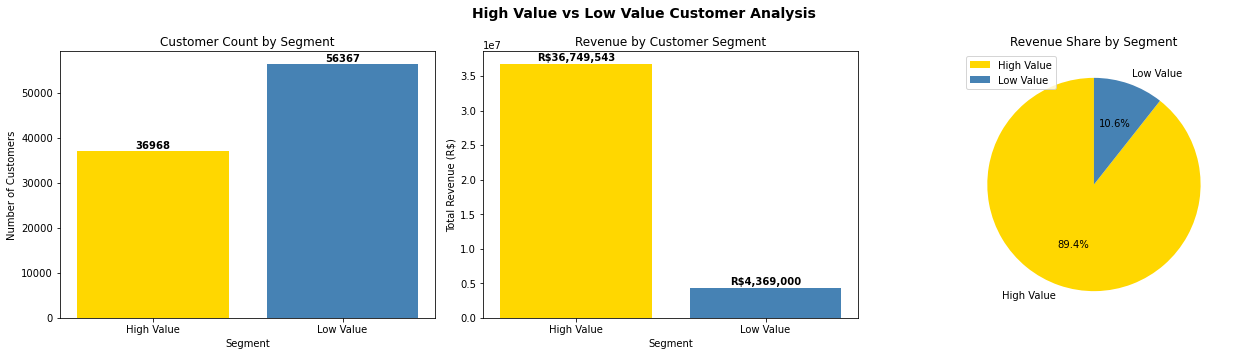

In [63]:
#Visualization of analysis of high value vs low value customers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Chart 1 — Customer Count
axes[0].bar(segment_counts.index,
            segment_counts.values,
            color=["gold", "steelblue"])
axes[0].set_title("Customer Count by Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 500, str(v), ha="center", fontweight="bold")
# Chart 2 — Revenue by Segment
axes[1].bar(segment_revenue.index,
            segment_revenue.values,
            color=["gold", "steelblue"])
axes[1].set_title("Revenue by Customer Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Total Revenue (R$)")
for i, v in enumerate(segment_revenue.values):
    axes[1].text(i, v + 500000, f"R${v:,.0f}", ha="center", fontweight="bold")
# Chart 3 — Revenue Percentage Pie
revenue_pct = (segment_revenue / segment_revenue.sum() * 100).round(2)
axes[2].pie(revenue_pct.values,
            labels=segment_revenue.index,
            autopct="%1.1f%%",
            colors=["gold", "steelblue"],
            startangle=90)
axes[2].set_title("Revenue Share by Segment")

plt.suptitle("High Value vs Low Value Customer Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

1C: Geographic Distribution

In [64]:
# Top 10 states by customer count
state_counts = master.groupby("customer_state")["customer_unique_id"].nunique().sort_values(ascending=False)
print("Top 10 States by Customer Count:\n", state_counts.head(5))
# Top 10 cities by customer count
city_counts = master.groupby("customer_city")["customer_unique_id"].nunique().sort_values(ascending=False)
print("\nTop 10 Cities by Customer Count:\n", city_counts.head(5))
# Revenue by state
state_revenue = master.groupby("customer_state")["total_order_value"].sum().sort_values(ascending=False)
print("\nTop 10 States by Revenue:\n", state_revenue.head(5))

Top 10 States by Customer Count:
 customer_state
SP    39143
RJ    11915
MG    10998
RS     5165
PR     4769
Name: customer_unique_id, dtype: int64

Top 10 Cities by Customer Count:
 customer_city
sao paulo         14527
rio de janeiro     6360
belo horizonte     2606
brasilia           2013
curitiba           1434
Name: customer_unique_id, dtype: int64

Top 10 States by Revenue:
 customer_state
SP    15785195.14
RJ     5694903.74
MG     4135939.74
PR     2326676.28
RS     2310138.04
Name: total_order_value, dtype: float64


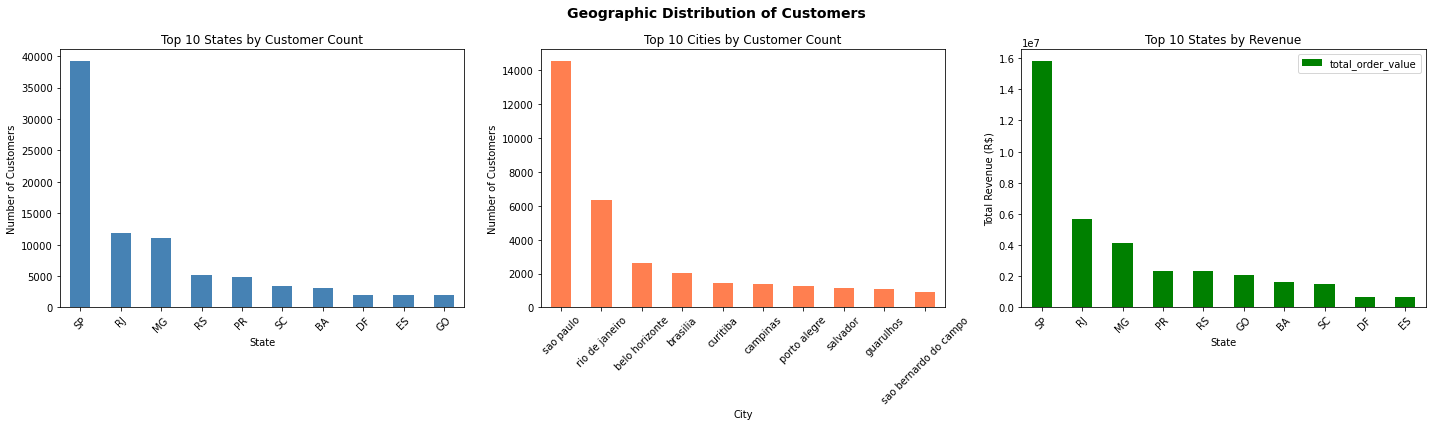

In [65]:
#Visualization of analysis of geographic distribution of customers and revenue
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Chart 1 — Top 10 States by Customer Count
state_counts.head(10).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 States by Customer Count")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=45)
# Chart 2 — Top 10 Cities by Customer Count
city_counts.head(10).plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Top 10 Cities by Customer Count")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Number of Customers")
axes[1].tick_params(axis="x", rotation=45)# Rotate x-axis labels for better readability
# Chart 3 — Top 10 States by Revenue
state_revenue.head(10).plot(kind="bar", ax=axes[2], color="green")
axes[2].set_title("Top 10 States by Revenue")
axes[2].set_xlabel("State")
axes[2].set_ylabel("Total Revenue (R$)")
axes[2].tick_params(axis="x", rotation=45) # Rotate x-axis labels for better readability
plt.suptitle("Geographic Distribution of Customers", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

2.Revenue and Order Analysis

 2A: Monthly Revenue Trends

In [66]:
# Extract year-month from order_purchase_timestamp
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M")
# Monthly revenue
monthly_revenue = master.groupby("order_month")["total_order_value"].sum().reset_index()
monthly_revenue.columns = ["month", "revenue"]
print("Monthly Revenue:\n", monthly_revenue)

Monthly Revenue:
       month     revenue
0   2016-10   128210.68
1   2016-12       19.62
2   2017-01   500152.90
3   2017-02   522849.54
4   2017-03   879951.35
5   2017-04   666551.16
6   2017-05  1219629.74
7   2017-06   954868.32
8   2017-07  1356856.21
9   2017-08  2316133.29
10  2017-09  2740734.55
11  2017-10  2555780.80
12  2017-11  3505794.32
13  2017-12  1758938.33
14  2018-01  2779780.91
15  2018-02  3427579.18
16  2018-03  2850749.29
17  2018-04  3072417.33
18  2018-05  2895005.00
19  2018-06  2386747.22
20  2018-07  2495315.19
21  2018-08  2104478.14


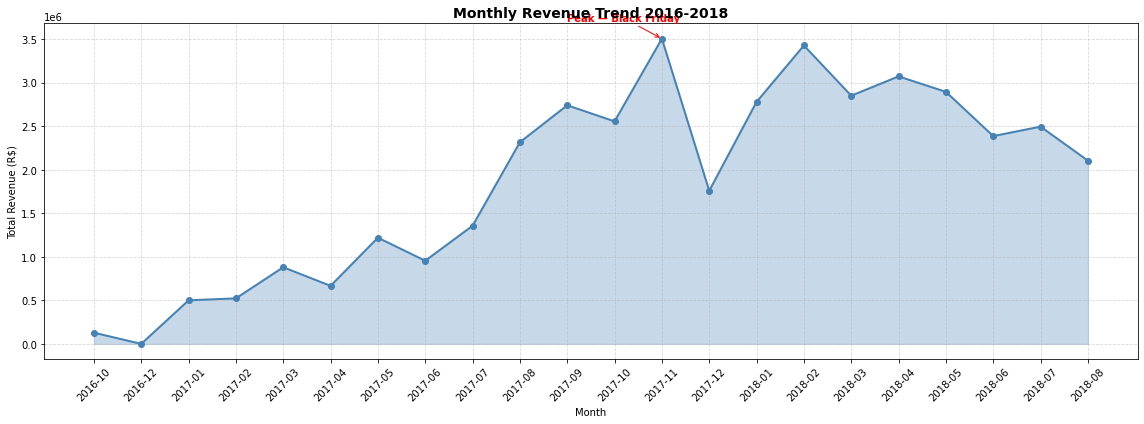

In [67]:
#Visualization of analysis of monthly revenue trends
fig, ax = plt.subplots(figsize=(16, 6))
# Convert period to string for plotting
monthly_revenue["month_str"] = monthly_revenue["month"].astype(str)
ax.plot(monthly_revenue["month_str"], 
        monthly_revenue["revenue"],
        marker="o", linewidth=2, color="steelblue")

ax.fill_between(monthly_revenue["month_str"],
                monthly_revenue["revenue"],
                alpha=0.3, color="steelblue")
# Highlight peak month
peak_idx = monthly_revenue["revenue"].idxmax()
ax.annotate("Peak — Black Friday",
            xy=(peak_idx, monthly_revenue["revenue"][peak_idx]),
            xytext=(peak_idx - 2, monthly_revenue["revenue"][peak_idx] + 200000),
            arrowprops=dict(arrowstyle="->", color="red"),
            color="red", fontweight="bold")
ax.set_title("Monthly Revenue Trend 2016-2018", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (R$)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

2B: Order Volume Trends

In [68]:
# Monthly order count
monthly_orders = master.groupby(
    "order_month")["order_id"].nunique().reset_index()
monthly_orders.columns = ["month", "order_count"]
print("Monthly Order Volume:\n", monthly_orders)

Monthly Order Volume:
       month  order_count
0   2016-10          265
1   2016-12            1
2   2017-01          748
3   2017-02         1641
4   2017-03         2546
5   2017-04         2303
6   2017-05         3545
7   2017-06         3135
8   2017-07         3872
9   2017-08         4193
10  2017-09         4149
11  2017-10         4478
12  2017-11         7288
13  2017-12         5513
14  2018-01         7069
15  2018-02         6555
16  2018-03         7003
17  2018-04         6798
18  2018-05         6749
19  2018-06         6096
20  2018-07         6156
21  2018-08         6351


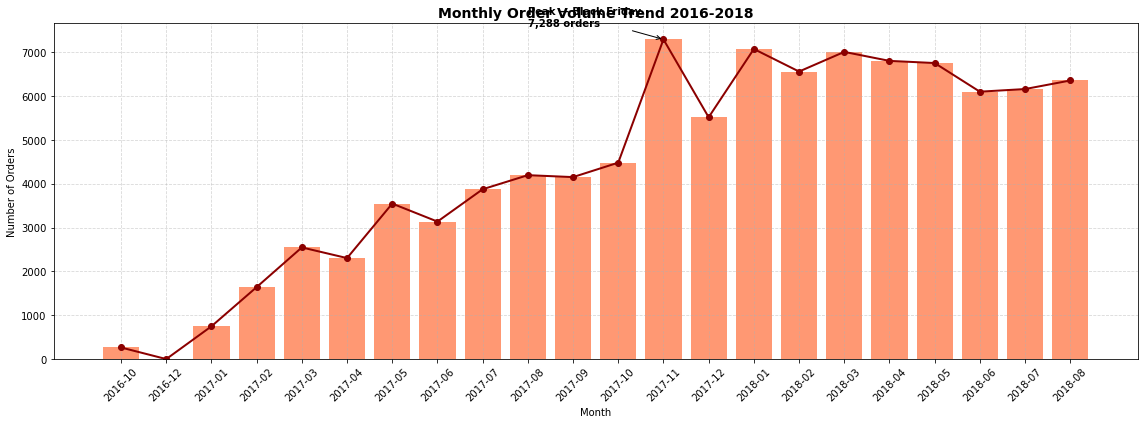

In [69]:
fig, ax = plt.subplots(figsize=(16, 6))
monthly_orders["month_str"] = monthly_orders["month"].astype(str)
ax.bar(monthly_orders["month_str"],
       monthly_orders["order_count"],
       color="coral", alpha=0.8)

ax.plot(monthly_orders["month_str"],
        monthly_orders["order_count"],
        marker="o", linewidth=2, color="darkred")

# Highlight peak
peak_idx = monthly_orders["order_count"].idxmax()
ax.annotate("Peak — Black Friday\n7,288 orders",
            xy=(peak_idx, monthly_orders["order_count"][peak_idx]),
            xytext=(peak_idx - 3, monthly_orders["order_count"][peak_idx] + 300),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontweight="bold")

ax.set_title("Monthly Order Volume Trend 2016-2018",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

2C: Peak Sales Periods

In [70]:
# Extract day of week and hour for peak analysis
master["order_dayofweek"] = master["order_purchase_timestamp"].dt.day_name()
master["order_hour"] = master["order_purchase_timestamp"].dt.hour
master["order_quarter"] = master["order_purchase_timestamp"].dt.quarter
# 1. Orders by day of week
day_orders = master.groupby(
    "order_dayofweek")["order_id"].nunique().reindex([
    "Monday", "Tuesday", "Wednesday", 
    "Thursday", "Friday", "Saturday", "Sunday"])
print("Orders by Day of Week:\n", day_orders)
# 2. Orders by hour
hour_orders = master.groupby("order_hour")["order_id"].nunique()
print("\nOrders by Hour:\n", hour_orders)
# 3. Orders by quarter
quarter_orders = master.groupby("order_quarter")["order_id"].nunique()
print("\nOrders by Quarter:\n", quarter_orders)

Orders by Day of Week:
 order_dayofweek
Monday       15701
Tuesday      15502
Wednesday    15074
Thursday     14319
Friday       13680
Saturday     10547
Sunday       11631
Name: order_id, dtype: int64

Orders by Hour:
 order_hour
0     2321
1     1132
2      496
3      259
4      203
5      182
6      477
7     1199
8     2906
9     4647
10    5978
11    6384
12    5799
13    6307
14    6382
15    6247
16    6474
17    5959
18    5585
19    5801
20    6007
21    6039
22    5656
23    4014
Name: order_id, dtype: int64

Orders by Quarter:
 order_quarter
1    25562
2    28626
3    24721
4    17545
Name: order_id, dtype: int64


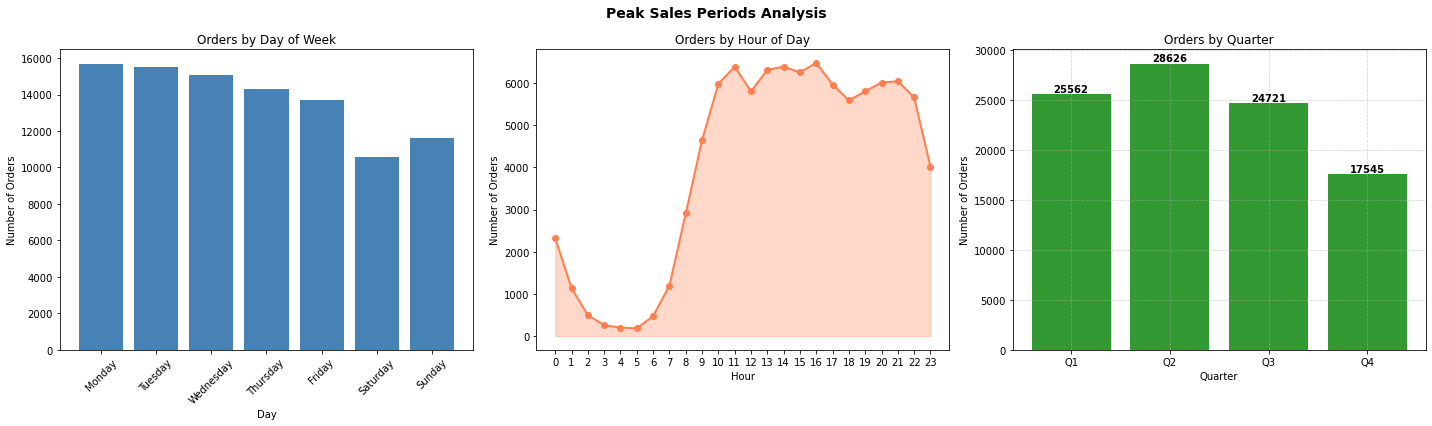

In [71]:
#Analysis of order patterns by day of week, hour, and quarter
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Orders by Day of Week
axes[0].bar(day_orders.index,
            day_orders.values,
            color="steelblue")
axes[0].set_title("Orders by Day of Week")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Number of Orders")
axes[0].tick_params(axis="x", rotation=45)

# Chart 2 — Orders by Hour
axes[1].plot(hour_orders.index,
             hour_orders.values,
             marker="o", linewidth=2, color="coral")
axes[1].fill_between(hour_orders.index,
                     hour_orders.values,
                     alpha=0.3, color="coral")
axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Number of Orders")
axes[1].set_xticks(range(0, 24))

# Chart 3 — Orders by Quarter
axes[2].bar(["Q1", "Q2", "Q3", "Q4"],
            quarter_orders.values,
            color="green", alpha=0.8)
axes[2].set_title("Orders by Quarter")
axes[2].set_xlabel("Quarter")
axes[2].set_ylabel("Number of Orders")
for i, v in enumerate(quarter_orders.values):
    axes[2].text(i, v + 200, str(v), ha="center", fontweight="bold")

plt.suptitle("Peak Sales Periods Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

3.Product Analysis

3A:•	Top-selling product categories 

In [72]:
# Top 10 categories by order count
category_orders = master.groupby(
    "product_category_name_english")["order_id"].nunique().sort_values(
    ascending=False)

print("Top 10 Categories by Order Count:\n", category_orders.head(10))

# Bottom 5 categories
print("\nBottom 5 Categories by Order Count:\n", category_orders.tail(5))

# Total unique categories
print("\nTotal Unique Categories:", category_orders.shape[0])

Top 10 Categories by Order Count:
 product_category_name_english
bed_bath_table           9271
health_beauty            8646
sports_leisure           7527
computers_accessories    6529
furniture_decor          6303
housewares               5743
watches_gifts            5493
telephony                4092
auto                     3809
toys                     3803
Name: order_id, dtype: int64

Bottom 5 Categories by Order Count:
 product_category_name_english
la_cuisine                   13
cds_dvds_musicals            12
pc_gamer                      7
fashion_childrens_clothes     7
security_and_services         2
Name: order_id, dtype: int64

Total Unique Categories: 74


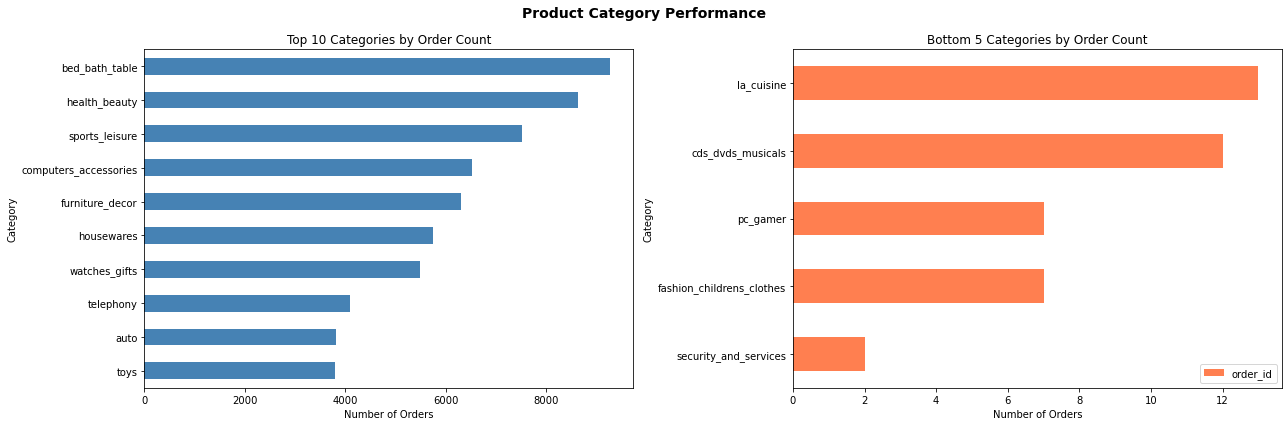

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1 — Top 10 Categories by Order Count
category_orders.head(10).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Categories by Order Count")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Category")
axes[0].invert_yaxis()

# Chart 2 — Bottom 5 Categories
category_orders.tail(5).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Bottom 5 Categories by Order Count")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Category")
axes[1].invert_yaxis()

plt.suptitle("Product Category Performance",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

3B: Revenue Contribution by Category

In [74]:
# Top 10 categories by revenue
category_revenue = master.groupby(
    "product_category_name_english")["total_order_value"].sum().sort_values(
    ascending=False)

print("Top 10 Categories by Revenue:\n", category_revenue.head(10))

# Revenue percentage contribution
category_revenue_pct = (category_revenue / 
                        category_revenue.sum() * 100).round(2)
print("\nTop 10 Revenue Contribution %:\n", category_revenue_pct.head(10))

# Cumulative revenue % (Pareto)
cumulative_pct = category_revenue_pct.cumsum()
print("\nHow many categories cover 80% revenue?", 
      (cumulative_pct <= 80).sum())

Top 10 Categories by Revenue:
 product_category_name_english
computers_accessories    4502654.62
bed_bath_table           3867654.96
furniture_decor          3708684.84
housewares               2579349.56
health_beauty            2494273.94
office_furniture         2328498.82
sports_leisure           2131022.80
auto                     2126168.07
garden_tools             2051392.43
watches_gifts            1983866.75
Name: total_order_value, dtype: float64

Top 10 Revenue Contribution %:
 product_category_name_english
computers_accessories    10.95
bed_bath_table            9.41
furniture_decor           9.02
housewares                6.27
health_beauty             6.07
office_furniture          5.66
sports_leisure            5.18
auto                      5.17
garden_tools              4.99
watches_gifts             4.82
Name: total_order_value, dtype: float64

How many categories cover 80% revenue? 15


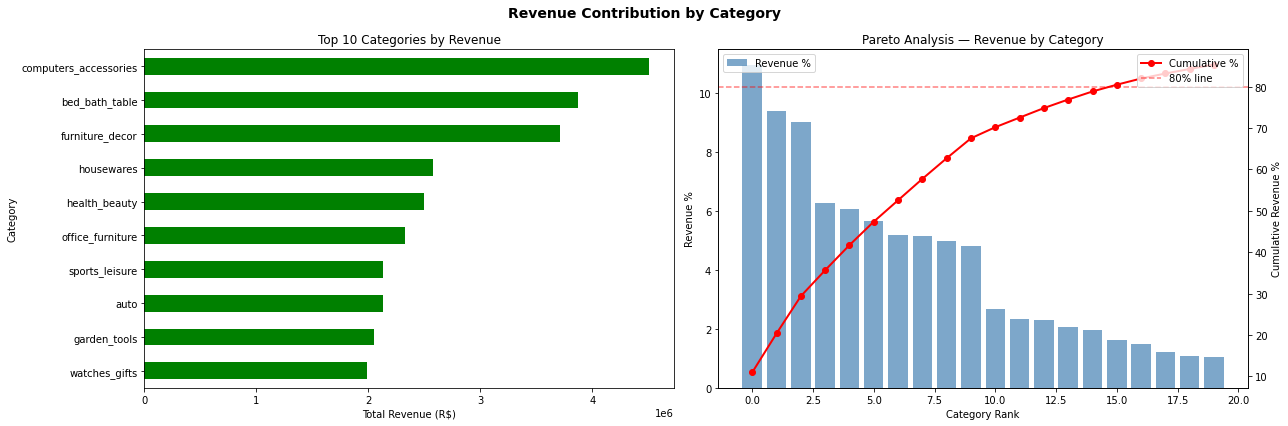

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1 — Top 10 Categories by Revenue
category_revenue.head(10).plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Top 10 Categories by Revenue")
axes[0].set_xlabel("Total Revenue (R$)")
axes[0].set_ylabel("Category")
axes[0].invert_yaxis()

# Chart 2 — Pareto Chart (Cumulative Revenue %)
axes[1].bar(range(len(category_revenue_pct.head(20))),
            category_revenue_pct.head(20).values,
            color="steelblue", alpha=0.7, label="Revenue %")
ax2 = axes[1].twinx()
ax2.plot(range(len(cumulative_pct.head(20))),
         cumulative_pct.head(20).values,
         color="red", marker="o", linewidth=2, label="Cumulative %")
ax2.axhline(y=80, color="red", linestyle="--", alpha=0.5, label="80% line")
axes[1].set_title("Pareto Analysis — Revenue by Category")
axes[1].set_xlabel("Category Rank")
axes[1].set_ylabel("Revenue %")
ax2.set_ylabel("Cumulative Revenue %")
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.suptitle("Revenue Contribution by Category",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

3C: Product Demand Distribution

In [76]:
# Orders per product
product_demand = master.groupby(
    "product_id")["order_id"].nunique().sort_values(ascending=False)

print("Top 10 Most Demanded Products:\n", product_demand.head(10))
print("\nBottom 10 Least Demanded Products:\n", product_demand.tail(10))

# Distribution stats
print("\nDemand Distribution Stats:\n", product_demand.describe())

# How many products have only 1 order
single_order_products = (product_demand == 1).sum()
print("\nProducts with only 1 order:", single_order_products)
print("Percentage:", round(single_order_products / len(product_demand) * 100, 2), "%")

Top 10 Most Demanded Products:
 product_id
99a4788cb24856965c36a24e339b6058    456
aca2eb7d00ea1a7b8ebd4e68314663af    425
422879e10f46682990de24d770e7f83d    352
d1c427060a0f73f6b889a5c7c61f2ac4    313
389d119b48cf3043d311335e499d9c6b    309
53b36df67ebb7c41585e8d54d6772e08    304
368c6c730842d78016ad823897a372db    291
53759a2ecddad2bb87a079a1f1519f73    287
154e7e31ebfa092203795c972e5804a6    262
2b4609f8948be18874494203496bc318    254
Name: order_id, dtype: int64

Bottom 10 Least Demanded Products:
 product_id
6a012e40ee0f3e0ca9b34bbdeedbdd2c    1
69ff1e4ad10ccba4d0e1ffc0aa771380    1
69fef0f440d7a4d03f5d883264132dc2    1
69fb24f0cd077f460768e66b89c3565e    1
69faf0d53eb73597d6cfd50175901a56    1
69f58c765fe75f61f1b098a6d0b0943e    1
69f1af20fc47db1c5136f570d7e71fb9    1
69eeb1281add8e5d8b916637f9f11a1b    1
69e8f74916646e186145f5648840ea9e    1
fffe9eeff12fcbd74a2f2b007dde0c58    1
Name: order_id, dtype: int64

Demand Distribution Stats:
 count    32210.000000
mean         3.10996

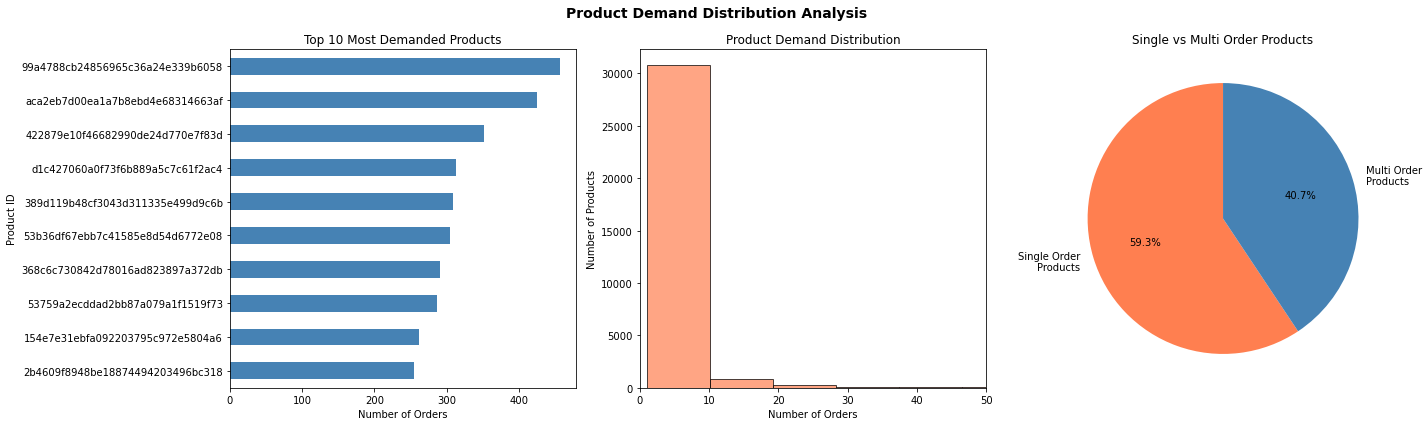

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Top 10 Most Demanded Products
product_demand.head(10).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Most Demanded Products")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Product ID")
axes[0].invert_yaxis()

# Chart 2 — Demand Distribution Histogram
axes[1].hist(product_demand.values, 
             bins=50, color="coral", 
             edgecolor="black", alpha=0.7)
axes[1].set_title("Product Demand Distribution")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Products")
axes[1].set_xlim(0, 50)  # Focus on 0-50 range

# Chart 3 — Single vs Multi Order Products
single = (product_demand == 1).sum()
multi  = (product_demand > 1).sum()
axes[2].pie([single, multi],
            labels=["Single Order\nProducts", "Multi Order\nProducts"],
            autopct="%1.1f%%",
            colors=["coral", "steelblue"],
            startangle=90)
axes[2].set_title("Single vs Multi Order Products")

plt.suptitle("Product Demand Distribution Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

4.Seller Analysis

4A:•	Top-performing sellers 

In [78]:
# Top 10 sellers by order count
seller_orders = master.groupby(
    "seller_id")["order_id"].nunique().sort_values(ascending=False)

print("Top 10 Sellers by Order Count:\n", seller_orders.head(10))

# Total unique sellers
print("\nTotal Unique Sellers:", seller_orders.shape[0])

# Distribution stats
print("\nSeller Order Distribution:\n", seller_orders.describe())

# Sellers with only 1 order
single_order_sellers = (seller_orders == 1).sum()
print("\nSellers with only 1 order:", single_order_sellers)
print("Percentage:", round(single_order_sellers / 
                           len(seller_orders) * 100, 2), "%")

Top 10 Sellers by Order Count:
 seller_id
6560211a19b47992c3666cc44a7e94c0    1819
4a3ca9315b744ce9f8e9374361493884    1772
cc419e0650a3c5ba77189a1882b7556a    1651
1f50f920176fa81dab994f9023523100    1399
da8622b14eb17ae2831f4ac5b9dab84a    1311
955fee9216a65b617aa5c0531780ce60    1261
7a67c85e85bb2ce8582c35f2203ad736    1142
ea8482cd71df3c1969d7b9473ff13abc    1132
4869f7a5dfa277a7dca6462dcf3b52b2    1124
3d871de0142ce09b7081e2b9d1733cb1    1064
Name: order_id, dtype: int64

Total Unique Sellers: 2970

Seller Order Distribution:
 count    2970.000000
mean       32.927609
std       105.388418
min         1.000000
25%         2.000000
50%         7.000000
75%        22.000000
max      1819.000000
Name: order_id, dtype: float64

Sellers with only 1 order: 536
Percentage: 18.05 %


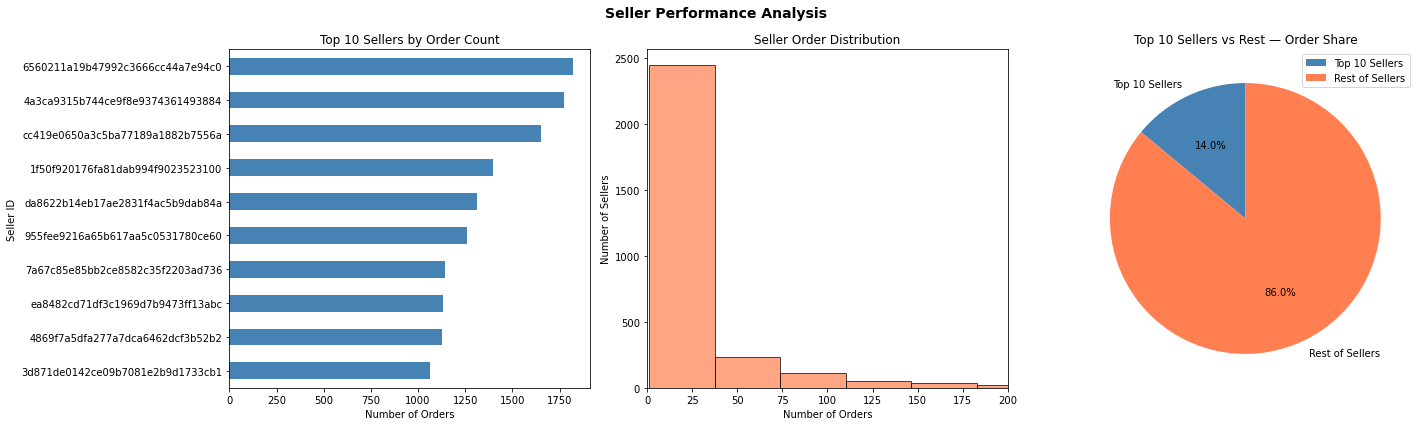

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Top 10 Sellers by Order Count
seller_orders.head(10).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Sellers by Order Count")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Seller ID")
axes[0].invert_yaxis()

# Chart 2 — Seller Order Distribution
axes[1].hist(seller_orders.values,
             bins=50, color="coral",
             edgecolor="black", alpha=0.7)
axes[1].set_title("Seller Order Distribution")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Sellers")
axes[1].set_xlim(0, 200)

# Chart 3 — Top 10 vs Rest Revenue
top_10_orders = seller_orders.head(10).sum()
rest_orders   = seller_orders.tail(len(seller_orders)-10).sum()
axes[2].pie([top_10_orders, rest_orders],
            labels=["Top 10 Sellers", "Rest of Sellers"],
            autopct="%1.1f%%",
            colors=["steelblue", "coral"],
            startangle=90)
axes[2].set_title("Top 10 Sellers vs Rest — Order Share")

plt.suptitle("Seller Performance Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

4B: Seller Contribution to Revenue

In [80]:
# Top 10 sellers by revenue
seller_revenue = master.groupby(
    "seller_id")["total_order_value"].sum().sort_values(ascending=False)

print("Top 10 Sellers by Revenue:\n", seller_revenue.head(10))

# Revenue percentage contribution
seller_revenue_pct = (seller_revenue / 
                      seller_revenue.sum() * 100).round(2)
print("\nTop 10 Revenue Contribution %:\n", seller_revenue_pct.head(10))

# Cumulative revenue % (Pareto)
cumulative_pct = seller_revenue_pct.cumsum()
print("\nHow many sellers cover 80% revenue?",
      (cumulative_pct <= 80).sum())

# Top 10 vs rest revenue share
top10_revenue = seller_revenue.head(10).sum()
rest_revenue  = seller_revenue.tail(len(seller_revenue)-10).sum()
total_revenue = seller_revenue.sum()
print(f"\nTop 10 Sellers Revenue: R${top10_revenue:,.2f} \
({round(top10_revenue/total_revenue*100, 2)}%)")
print(f"Rest of Sellers Revenue: R${rest_revenue:,.2f} \
({round(rest_revenue/total_revenue*100, 2)}%)")

Top 10 Sellers by Revenue:
 seller_id
7c67e1448b00f6e969d365cea6b010ab    2106566.35
1f50f920176fa81dab994f9023523100    1135935.97
8e6d7754bc7e0f22c96d255ebda59eba    1045770.94
b37c4c02bda3161a7546a4e6d222d5b2    1004522.56
1025f0e2d44d7041d6cf58b6550e0bfa     939520.60
ce27a3cc3c8cc1ea79d11e561e9bebb6     922540.83
25c5c91f63607446a97b143d2d535d31     726534.09
da8622b14eb17ae2831f4ac5b9dab84a     577240.46
955fee9216a65b617aa5c0531780ce60     549241.22
4a3ca9315b744ce9f8e9374361493884     524970.27
Name: total_order_value, dtype: float64

Top 10 Revenue Contribution %:
 seller_id
7c67e1448b00f6e969d365cea6b010ab    5.12
1f50f920176fa81dab994f9023523100    2.76
8e6d7754bc7e0f22c96d255ebda59eba    2.54
b37c4c02bda3161a7546a4e6d222d5b2    2.44
1025f0e2d44d7041d6cf58b6550e0bfa    2.28
ce27a3cc3c8cc1ea79d11e561e9bebb6    2.24
25c5c91f63607446a97b143d2d535d31    1.77
da8622b14eb17ae2831f4ac5b9dab84a    1.40
955fee9216a65b617aa5c0531780ce60    1.34
4a3ca9315b744ce9f8e9374361493884    1.28

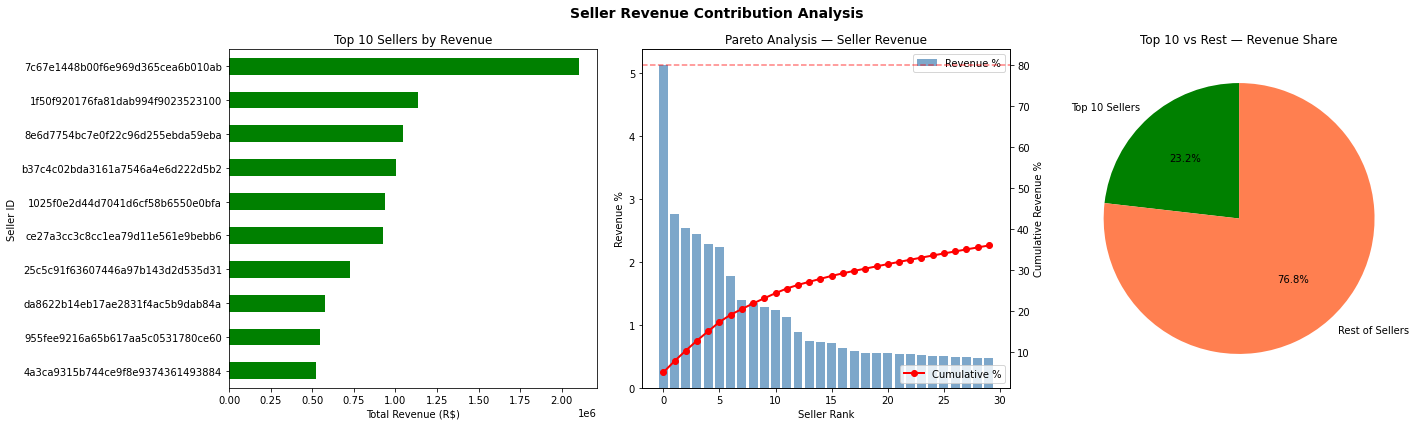

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Top 10 Sellers by Revenue
seller_revenue.head(10).plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Top 10 Sellers by Revenue")
axes[0].set_xlabel("Total Revenue (R$)")
axes[0].set_ylabel("Seller ID")
axes[0].invert_yaxis()

# Chart 2 — Pareto Chart
axes[1].bar(range(len(seller_revenue_pct.head(30))),
            seller_revenue_pct.head(30).values,
            color="steelblue", alpha=0.7, label="Revenue %")
ax2 = axes[1].twinx()
ax2.plot(range(len(cumulative_pct.head(30))),
         cumulative_pct.head(30).values,
         color="red", marker="o", linewidth=2, label="Cumulative %")
ax2.axhline(y=80, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("Pareto Analysis — Seller Revenue")
axes[1].set_xlabel("Seller Rank")
axes[1].set_ylabel("Revenue %")
ax2.set_ylabel("Cumulative Revenue %")
axes[1].legend(loc="upper right")
ax2.legend(loc="center right")

# Chart 3 — Top 10 vs Rest Revenue Share
axes[2].pie([top10_revenue, rest_revenue],
            labels=["Top 10 Sellers", "Rest of Sellers"],
            autopct="%1.1f%%",
            colors=["green", "coral"],
            startangle=90)
axes[2].set_title("Top 10 vs Rest — Revenue Share")

plt.suptitle("Seller Revenue Contribution Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

4C: Seller Distribution

In [82]:
# Seller distribution by state
seller_state = master.groupby(
    "seller_state")["seller_id"].nunique().sort_values(ascending=False)

print("Sellers by State:\n", seller_state.head(10))

# Seller distribution by city
seller_city = master.groupby(
    "seller_city")["seller_id"].nunique().sort_values(ascending=False)

print("\nTop 10 Seller Cities:\n", seller_city.head(10))

# Average revenue per seller by state
seller_state_revenue = master.groupby(
    "seller_state")["total_order_value"].sum().sort_values(ascending=False)

print("\nTop 10 States by Seller Revenue:\n", seller_state_revenue.head(10))

Sellers by State:
 seller_state
SP    1769
PR     335
MG     236
SC     184
RJ     163
RS     125
GO      39
DF      30
ES      22
BA      18
Name: seller_id, dtype: int64

Top 10 Seller Cities:
 seller_city
sao paulo         661
curitiba          124
rio de janeiro     92
belo horizonte     65
ribeirao preto     50
ibitinga           49
guarulhos          48
santo andre        44
maringa            40
campinas           40
Name: seller_id, dtype: int64

Top 10 States by Seller Revenue:
 seller_state
SP    28764498.43
PR     3267909.60
MG     3005979.77
RJ     1800009.10
SC     1490804.81
RS     1105509.69
BA      635186.71
GO      287882.08
DF      218268.24
PE      214089.13
Name: total_order_value, dtype: float64


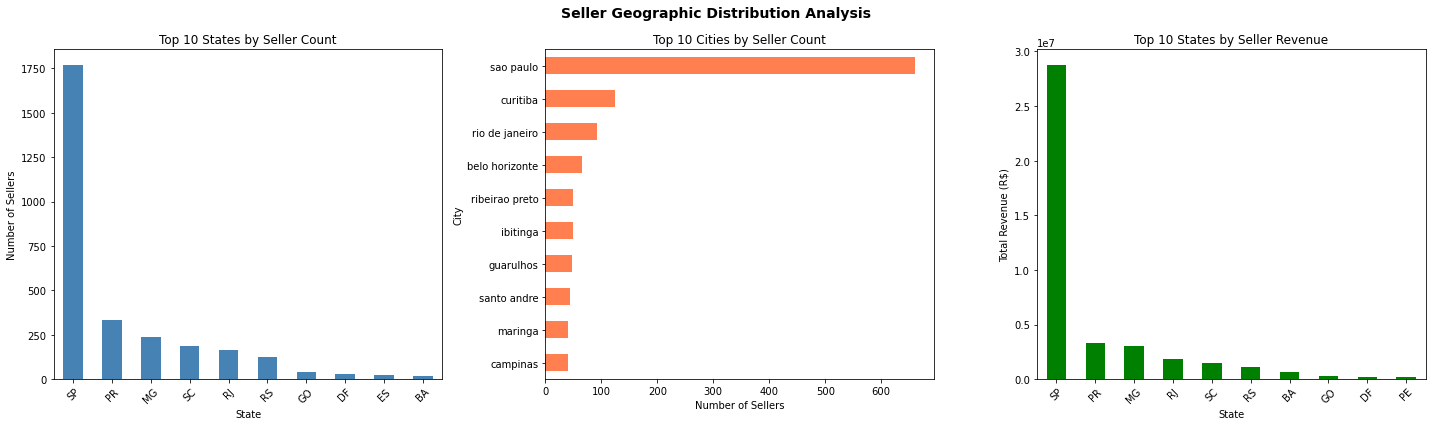

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Sellers by State
seller_state.head(10).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 States by Seller Count")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Number of Sellers")
axes[0].tick_params(axis="x", rotation=45)

# Chart 2 — Top 10 Seller Cities
seller_city.head(10).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Top 10 Cities by Seller Count")
axes[1].set_xlabel("Number of Sellers")
axes[1].set_ylabel("City")
axes[1].invert_yaxis()

# Chart 3 — Revenue by Seller State
seller_state_revenue.head(10).plot(kind="bar", ax=axes[2], color="green")
axes[2].set_title("Top 10 States by Seller Revenue")
axes[2].set_xlabel("State")
axes[2].set_ylabel("Total Revenue (R$)")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Seller Geographic Distribution Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

5.Review and Satisfaction Analysis

5A:•	Distribution of review scores 

In [84]:
# Review score distribution
review_dist = master.groupby(
    "review_score")["order_id"].nunique().sort_index()

print("Review Score Distribution:\n", review_dist)

# Percentage
review_pct = (review_dist / review_dist.sum() * 100).round(2)
print("\nReview Score Percentage:\n", review_pct)

# Average review score
print("\nAverage Review Score:", round(master["review_score"].mean(), 2))

# Positive vs Negative
positive = review_pct[review_pct.index >= 4].sum()
negative = review_pct[review_pct.index <= 2].sum()
neutral  = review_pct[review_pct.index == 3].sum()
print(f"\nPositive (4-5) : {positive}%")
print(f"Neutral  (3)   : {neutral}%")
print(f"Negative (1-2) : {negative}%")

Review Score Distribution:
 review_score
0.0      646
1.0     9379
2.0     2937
3.0     7941
4.0    18939
5.0    56801
Name: order_id, dtype: int64

Review Score Percentage:
 review_score
0.0     0.67
1.0     9.70
2.0     3.04
3.0     8.22
4.0    19.60
5.0    58.77
Name: order_id, dtype: float64

Average Review Score: 4.05

Positive (4-5) : 78.37%
Neutral  (3)   : 8.22%
Negative (1-2) : 13.41%


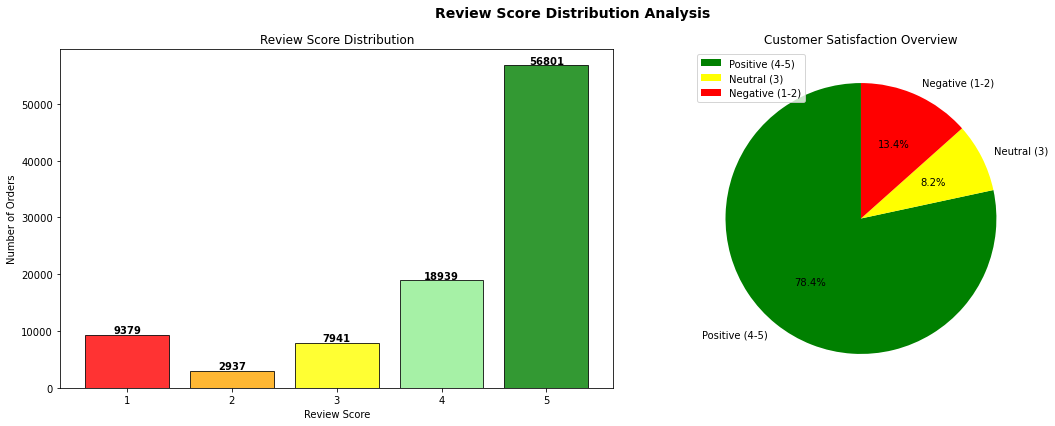

In [85]:
#Analysis of review scores by customer segment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Filter out 0 scores for cleaner visualization
review_dist_clean = review_dist[review_dist.index > 0]
review_pct_clean  = review_pct[review_pct.index > 0]

# Chart 1 — Review Score Distribution Bar
colors = ["red", "orange", "yellow", "lightgreen", "green"]
axes[0].bar(review_dist_clean.index,
            review_dist_clean.values,
            color=colors, edgecolor="black", alpha=0.8)
axes[0].set_title("Review Score Distribution")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Number of Orders")
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, (score, count) in enumerate(review_dist_clean.items()):
    axes[0].text(score, count + 300, str(count),
                 ha="center", fontweight="bold")

# Chart 2 — Positive vs Neutral vs Negative Pie
axes[1].pie([positive, neutral, negative],
            labels=["Positive (4-5)", "Neutral (3)", "Negative (1-2)"],
            autopct="%1.1f%%",
            colors=["green", "yellow", "red"],
            startangle=90)
axes[1].set_title("Customer Satisfaction Overview")

plt.suptitle("Review Score Distribution Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

5B: Relationship Between Delivery Time and Ratings

In [86]:
# Average delivery time per review score
delivery_vs_score = master[master["review_score"] > 0].groupby(
    "review_score")["delivery_time_days"].mean().round(2)

print("Average Delivery Time by Review Score:\n", delivery_vs_score)

# Average delay days per review score
delay_vs_score = master[master["review_score"] > 0].groupby(
    "review_score")["delivery_delay_days"].mean().round(2)

print("\nAverage Delivery Delay by Review Score:\n", delay_vs_score)

# Correlation between delivery time and review score
correlation = master[master["review_score"] > 0][
    ["review_score", "delivery_time_days", 
     "delivery_delay_days"]].corr()

print("\nCorrelation Matrix:\n", correlation)

Average Delivery Time by Review Score:
 review_score
1.0    19.09
2.0    15.38
3.0    13.55
4.0    11.78
5.0    10.20
Name: delivery_time_days, dtype: float64

Average Delivery Delay by Review Score:
 review_score
1.0    -5.31
2.0    -9.04
3.0   -10.42
4.0   -11.77
5.0   -12.74
Name: delivery_delay_days, dtype: float64

Correlation Matrix:
                      review_score  delivery_time_days  delivery_delay_days
review_score             1.000000           -0.302596            -0.228152
delivery_time_days      -0.302596            1.000000             0.591853
delivery_delay_days     -0.228152            0.591853             1.000000


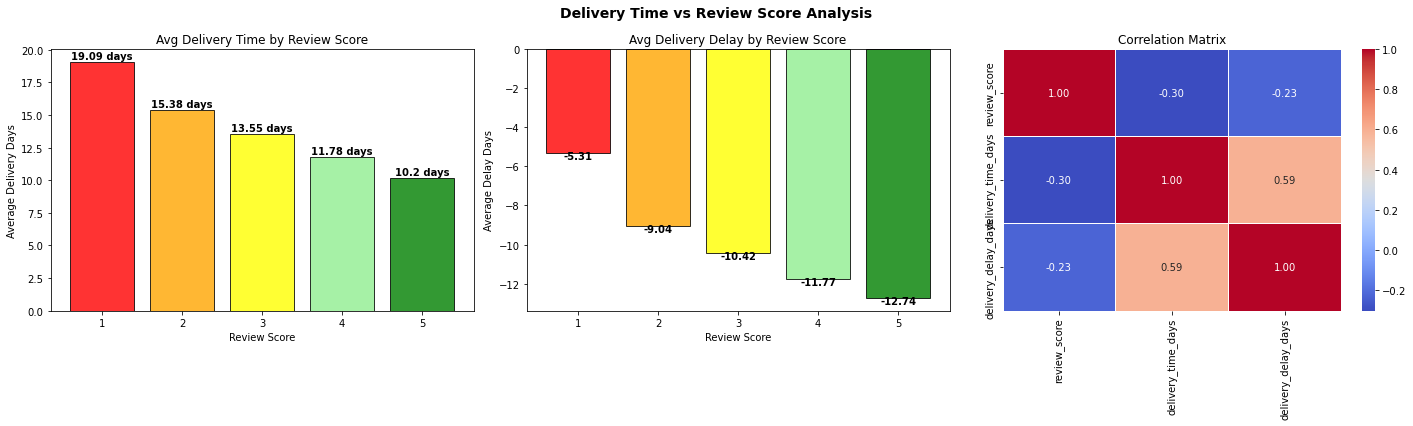

In [87]:
#Analysis of relashionship between delivery performance and review scores
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Delivery Time vs Review Score
axes[0].bar(delivery_vs_score.index,
            delivery_vs_score.values,
            color=["red", "orange", "yellow", 
                   "lightgreen", "green"],
            edgecolor="black", alpha=0.8)
axes[0].set_title("Avg Delivery Time by Review Score")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Average Delivery Days")
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, (score, days) in enumerate(delivery_vs_score.items()):
    axes[0].text(score, days + 0.2, f"{days} days",
                 ha="center", fontweight="bold")

# Chart 2 — Delivery Delay vs Review Score
axes[1].bar(delay_vs_score.index,
            delay_vs_score.values,
            color=["red", "orange", "yellow",
                   "lightgreen", "green"],
            edgecolor="black", alpha=0.8)
axes[1].set_title("Avg Delivery Delay by Review Score")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Average Delay Days")
axes[1].set_xticks([1, 2, 3, 4, 5])
for i, (score, days) in enumerate(delay_vs_score.items()):
    axes[1].text(score, days - 0.3, f"{days}",
                 ha="center", fontweight="bold")

# Chart 3 — Correlation Heatmap
sns.heatmap(correlation,
            annot=True, fmt=".2f",
            cmap="coolwarm",
            ax=axes[2],
            linewidths=0.5)
axes[2].set_title("Correlation Matrix")

plt.suptitle("Delivery Time vs Review Score Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

5c:•	Identification of dissatisfaction patterns 

In [88]:
# Filter only negative reviews (1-2 stars)
negative_reviews = master[master["review_score"] <= 2]

print("Total Negative Reviews:", negative_reviews["order_id"].nunique())

# 1. Which categories get most negative reviews
negative_by_category = negative_reviews.groupby(
    "product_category_name_english")["order_id"].nunique().sort_values(
    ascending=False)

print("\nTop 10 Categories with Negative Reviews:\n", 
      negative_by_category.head(10))

# 2. Which states have most negative reviews
negative_by_state = negative_reviews.groupby(
    "customer_state")["order_id"].nunique().sort_values(ascending=False)

print("\nTop 10 States with Negative Reviews:\n", 
      negative_by_state.head(10))

# 3. Negative reviews by delivery time bucket
negative_reviews = negative_reviews.copy()
negative_reviews["delivery_bucket"] = pd.cut(
    negative_reviews["delivery_time_days"],
    bins=[0, 7, 14, 21, 30, 200],
    labels=["0-7 days", "8-14 days", 
            "15-21 days", "22-30 days", "30+ days"])

negative_by_delivery = negative_reviews.groupby(
    "delivery_bucket")["order_id"].nunique()

print("\nNegative Reviews by Delivery Time:\n", negative_by_delivery)

Total Negative Reviews: 12954

Top 10 Categories with Negative Reviews:
 product_category_name_english
bed_bath_table           1579
health_beauty            1032
furniture_decor          1017
computers_accessories     981
sports_leisure            897
watches_gifts             789
housewares                709
telephony                 599
auto                      512
toys                      460
Name: order_id, dtype: int64

Top 10 States with Negative Reviews:
 customer_state
SP    4539
RJ    2385
MG    1398
RS     655
BA     578
PR     558
SC     485
ES     298
DF     286
GO     271
Name: order_id, dtype: int64

Negative Reviews by Delivery Time:
 delivery_bucket
0-7 days      2702
8-14 days     3571
15-21 days    2021
22-30 days    1931
30+ days      2726
Name: order_id, dtype: int64


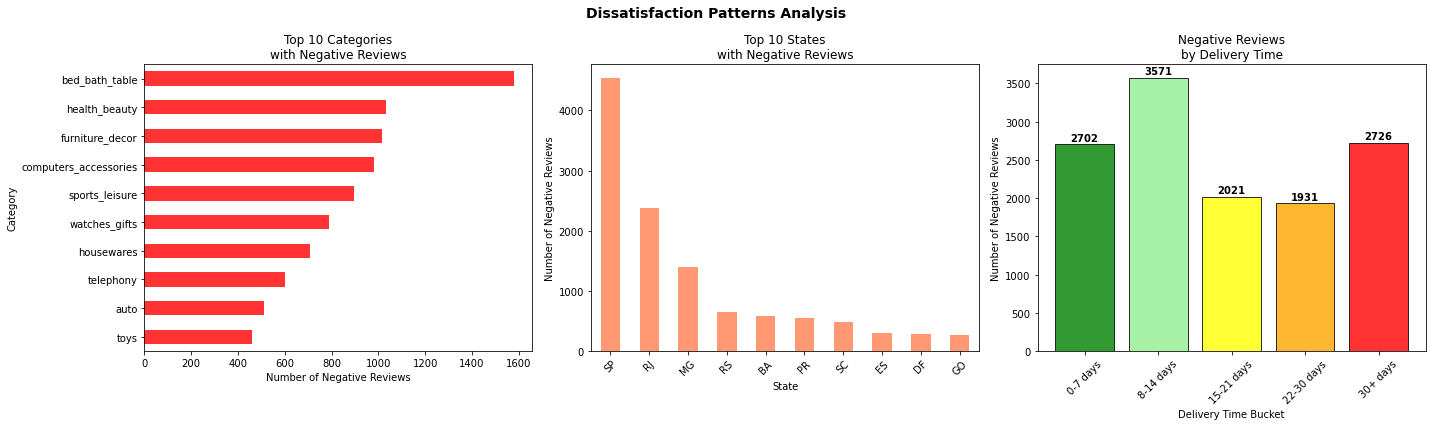

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Top 10 Categories with Negative Reviews
negative_by_category.head(10).plot(kind="barh", 
                                    ax=axes[0], color="red",
                                    alpha=0.8)
axes[0].set_title("Top 10 Categories\nwith Negative Reviews")
axes[0].set_xlabel("Number of Negative Reviews")
axes[0].set_ylabel("Category")
axes[0].invert_yaxis()

# Chart 2 — Negative Reviews by State
negative_by_state.head(10).plot(kind="bar",
                                 ax=axes[1], color="coral",
                                 alpha=0.8)
axes[1].set_title("Top 10 States\nwith Negative Reviews")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Number of Negative Reviews")
axes[1].tick_params(axis="x", rotation=45)

# Chart 3 — Negative Reviews by Delivery Time
axes[2].bar(negative_by_delivery.index,
            negative_by_delivery.values,
            color=["green", "lightgreen", 
                   "yellow", "orange", "red"],
            edgecolor="black", alpha=0.8)
axes[2].set_title("Negative Reviews\nby Delivery Time")
axes[2].set_xlabel("Delivery Time Bucket")
axes[2].set_ylabel("Number of Negative Reviews")
axes[2].tick_params(axis="x", rotation=45)
for i, v in enumerate(negative_by_delivery.values):
    axes[2].text(i, v + 50, str(v),
                 ha="center", fontweight="bold")

plt.suptitle("Dissatisfaction Patterns Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Step 6: Data Visualization

6A:Time Series Plot (Sales Trends)

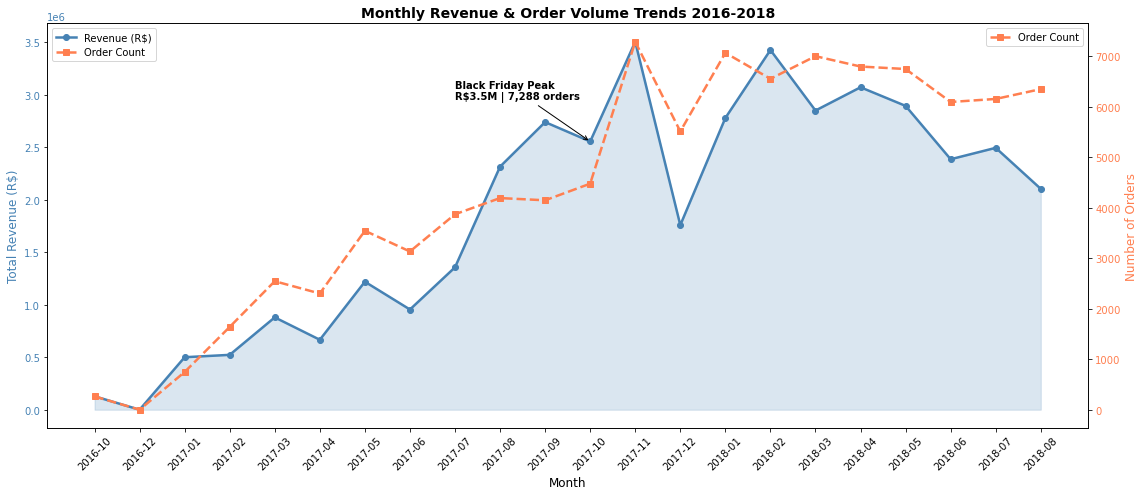

In [90]:
fig, ax1 = plt.subplots(figsize=(16, 7))

# Convert month to string
monthly_revenue["month_str"] = monthly_revenue["month"].astype(str)
monthly_orders["month_str"]  = monthly_orders["month"].astype(str)

# Primary axis — Revenue
ax1.plot(monthly_revenue["month_str"],
         monthly_revenue["revenue"],
         marker="o", linewidth=2.5,
         color="steelblue", label="Revenue (R$)")
ax1.fill_between(monthly_revenue["month_str"],
                 monthly_revenue["revenue"],
                 alpha=0.2, color="steelblue")
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Total Revenue (R$)", fontsize=12, color="steelblue")
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(axis="y", labelcolor="steelblue")

# Secondary axis — Order Volume
ax2 = ax1.twinx()
ax2.plot(monthly_orders["month_str"],
         monthly_orders["order_count"],
         marker="s", linewidth=2.5,
         color="coral", linestyle="--",
         label="Order Count")
ax2.set_ylabel("Number of Orders", fontsize=12, color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

# Highlight peak month
ax1.annotate("Black Friday Peak\nR$3.5M | 7,288 orders",
             xy=(11, monthly_revenue["revenue"][11]),
             xytext=(8, monthly_revenue["revenue"][11] + 400000),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontweight="bold", fontsize=10)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Monthly Revenue & Order Volume Trends 2016-2018",fontsize=14, fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()

6B:•	Bar charts (category performance) 

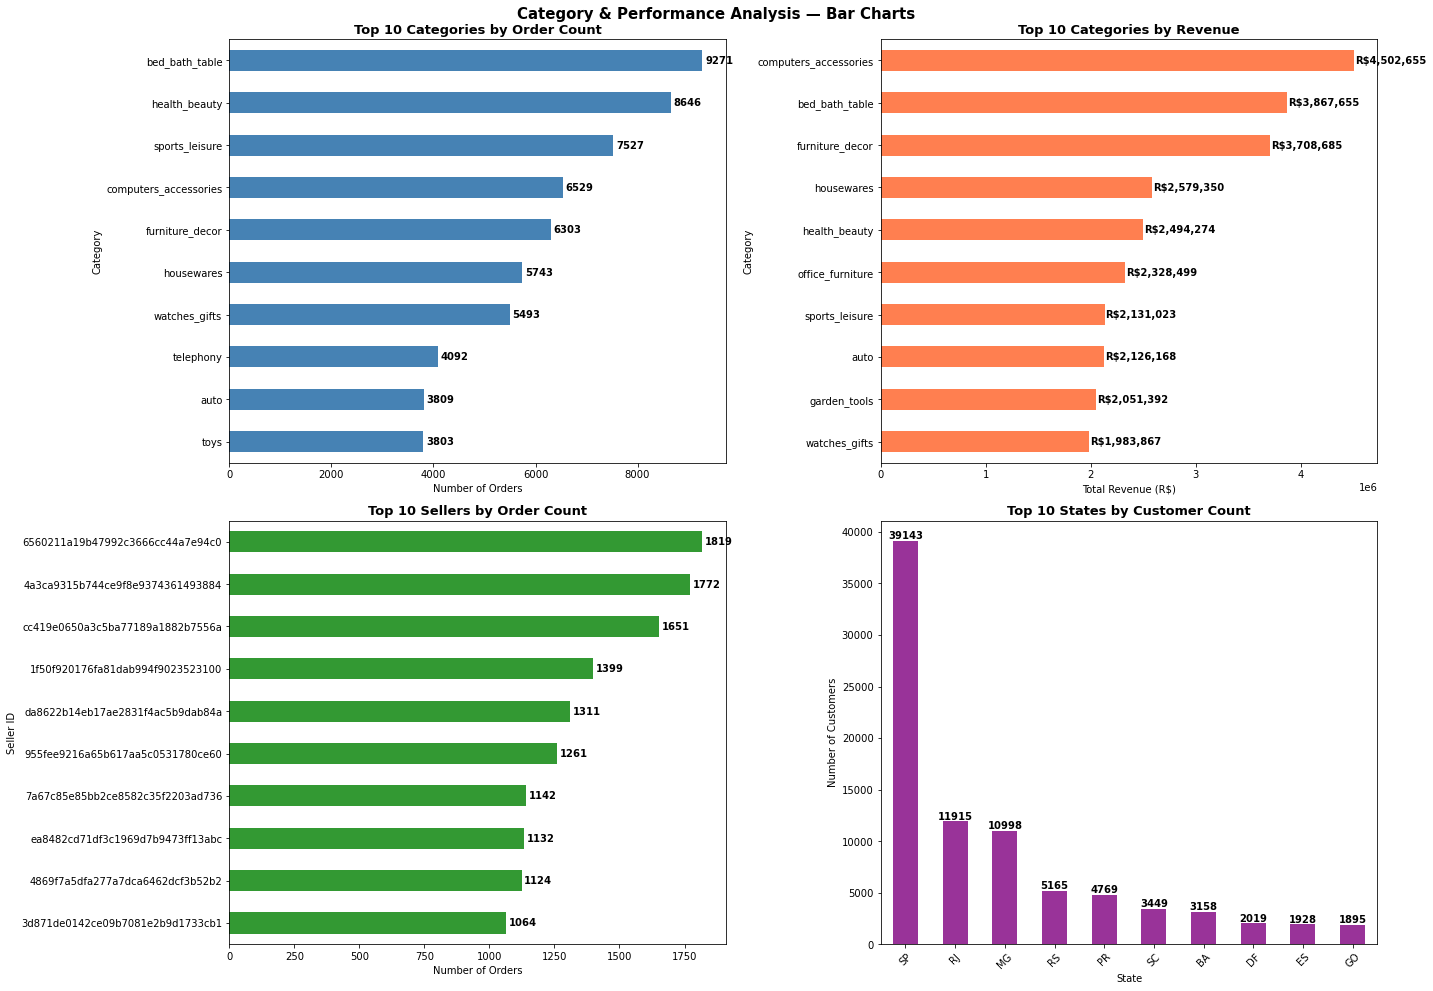

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Chart 1 — Top 10 Categories by Order Count
category_orders.head(10).plot(kind="barh", 
                               ax=axes[0,0], 
                               color="steelblue")
axes[0,0].set_title("Top 10 Categories by Order Count", 
                     fontsize=13, fontweight="bold")
axes[0,0].set_xlabel("Number of Orders")
axes[0,0].set_ylabel("Category")
axes[0,0].invert_yaxis()
for i, v in enumerate(category_orders.head(10).values):
    axes[0,0].text(v + 50, i, str(v), 
                   va="center", fontweight="bold")

# Chart 2 — Top 10 Categories by Revenue
category_revenue.head(10).plot(kind="barh",
                                ax=axes[0,1],
                                color="coral")
axes[0,1].set_title("Top 10 Categories by Revenue",
                     fontsize=13, fontweight="bold")
axes[0,1].set_xlabel("Total Revenue (R$)")
axes[0,1].set_ylabel("Category")
axes[0,1].invert_yaxis()
for i, v in enumerate(category_revenue.head(10).values):
    axes[0,1].text(v + 10000, i, f"R${v:,.0f}",
                   va="center", fontweight="bold")

# Chart 3 — Top 10 Sellers by Order Count
seller_orders.head(10).plot(kind="barh",
                             ax=axes[1,0],
                             color="green", alpha=0.8)
axes[1,0].set_title("Top 10 Sellers by Order Count",
                     fontsize=13, fontweight="bold")
axes[1,0].set_xlabel("Number of Orders")
axes[1,0].set_ylabel("Seller ID")
axes[1,0].invert_yaxis()
for i, v in enumerate(seller_orders.head(10).values):
    axes[1,0].text(v + 10, i, str(v),
                   va="center", fontweight="bold")

# Chart 4 — Top 10 States by Customer Count
state_counts.head(10).plot(kind="bar",
                            ax=axes[1,1],
                            color="purple", alpha=0.8)
axes[1,1].set_title("Top 10 States by Customer Count",
                     fontsize=13, fontweight="bold")
axes[1,1].set_xlabel("State")
axes[1,1].set_ylabel("Number of Customers")
axes[1,1].tick_params(axis="x", rotation=45)
for i, v in enumerate(state_counts.head(10).values):
    axes[1,1].text(i, v + 200, str(v),
                   ha="center", fontweight="bold")

plt.suptitle("Category & Performance Analysis — Bar Charts",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

6c:•	Histograms (distribution analysis) 

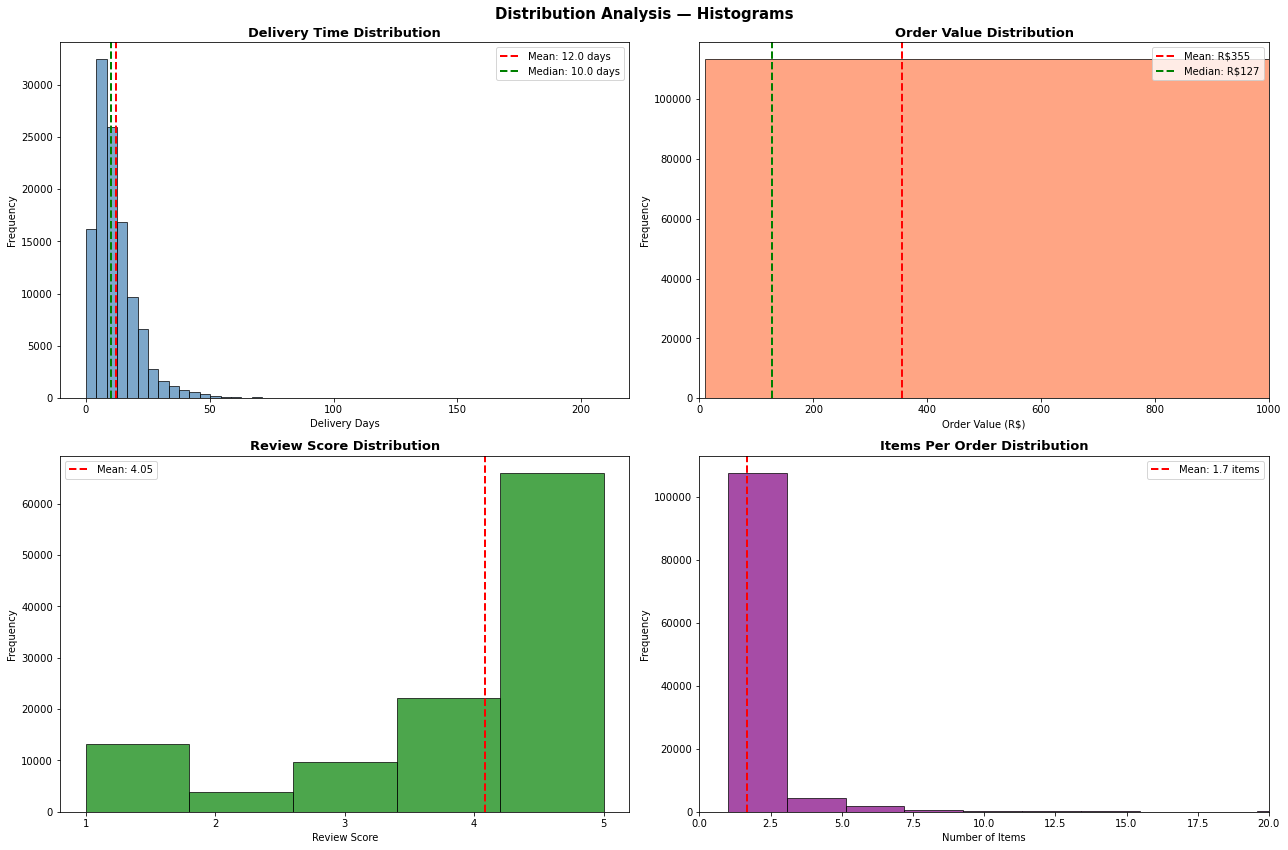

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart 1 — Delivery Time Distribution
axes[0,0].hist(master["delivery_time_days"],
               bins=50, color="steelblue",
               edgecolor="black", alpha=0.7)
axes[0,0].set_title("Delivery Time Distribution",
                     fontsize=13, fontweight="bold")
axes[0,0].set_xlabel("Delivery Days")
axes[0,0].set_ylabel("Frequency")
axes[0,0].axvline(master["delivery_time_days"].mean(),
                  color="red", linestyle="--", linewidth=2,
                  label=f'Mean: {master["delivery_time_days"].mean():.1f} days')
axes[0,0].axvline(master["delivery_time_days"].median(),
                  color="green", linestyle="--", linewidth=2,
                  label=f'Median: {master["delivery_time_days"].median():.1f} days')
axes[0,0].legend()

# Chart 2 — Order Value Distribution
axes[0,1].hist(master["total_order_value"],
               bins=50, color="coral",
               edgecolor="black", alpha=0.7)
axes[0,1].set_title("Order Value Distribution",
                     fontsize=13, fontweight="bold")
axes[0,1].set_xlabel("Order Value (R$)")
axes[0,1].set_ylabel("Frequency")
axes[0,1].set_xlim(0, 1000)
axes[0,1].axvline(master["total_order_value"].mean(),
                  color="red", linestyle="--", linewidth=2,
                  label=f'Mean: R${master["total_order_value"].mean():.0f}')
axes[0,1].axvline(master["total_order_value"].median(),
                  color="green", linestyle="--", linewidth=2,
                  label=f'Median: R${master["total_order_value"].median():.0f}')
axes[0,1].legend()

# Chart 3 — Review Score Distribution
axes[1,0].hist(master[master["review_score"] > 0]["review_score"],
               bins=5, color="green",
               edgecolor="black", alpha=0.7)
axes[1,0].set_title("Review Score Distribution",
                     fontsize=13, fontweight="bold")
axes[1,0].set_xlabel("Review Score")
axes[1,0].set_ylabel("Frequency")
axes[1,0].set_xticks([1, 2, 3, 4, 5])
axes[1,0].axvline(master[master["review_score"] > 0]["review_score"].mean(),
                  color="red", linestyle="--", linewidth=2,
                  label=f'Mean: {master["review_score"].mean():.2f}')
axes[1,0].legend()

# Chart 4 — Items Per Order Distribution
axes[1,1].hist(master["items_per_order"],
               bins=30, color="purple",
               edgecolor="black", alpha=0.7)
axes[1,1].set_title("Items Per Order Distribution",
                     fontsize=13, fontweight="bold")
axes[1,1].set_xlabel("Number of Items")
axes[1,1].set_ylabel("Frequency")
axes[1,1].set_xlim(0, 20)
axes[1,1].axvline(master["items_per_order"].mean(),
                  color="red", linestyle="--", linewidth=2,
                  label=f'Mean: {master["items_per_order"].mean():.1f} items')
axes[1,1].legend()

plt.suptitle("Distribution Analysis — Histograms",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

6d:•	Box plots (outlier detection) 

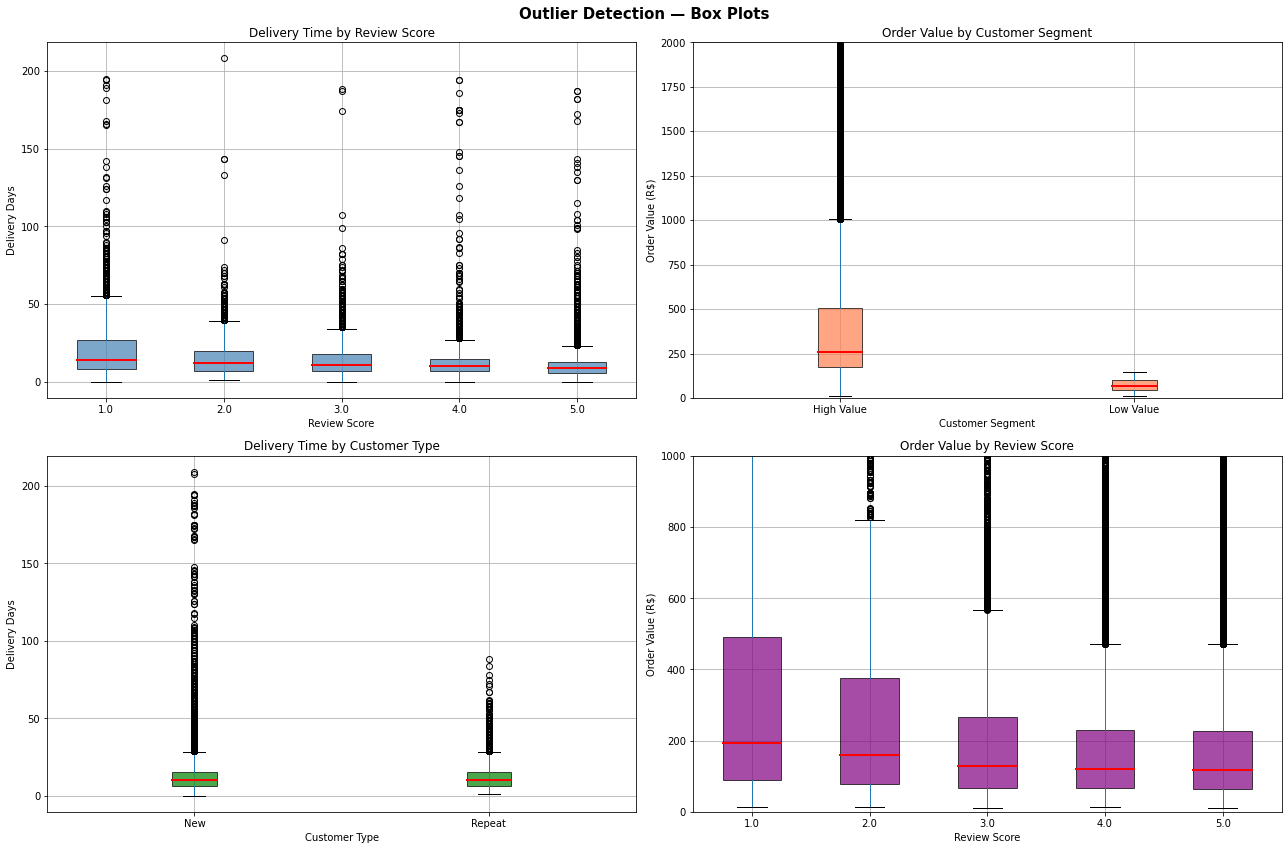

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart 1 — Delivery Time by Review Score
master[master["review_score"] > 0].boxplot(
    column="delivery_time_days",
    by="review_score",
    ax=axes[0,0],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7),
    medianprops=dict(color="red", linewidth=2))
axes[0,0].set_title("Delivery Time by Review Score",
                     fontsize=13, fontweight="bold")
axes[0,0].set_xlabel("Review Score")
axes[0,0].set_ylabel("Delivery Days")
plt.sca(axes[0,0])
plt.title("Delivery Time by Review Score")

# Chart 2 — Order Value by Customer Segment
master.boxplot(column="total_order_value",
               by="customer_segment",
               ax=axes[0,1],
               patch_artist=True,
               boxprops=dict(facecolor="coral", alpha=0.7),
               medianprops=dict(color="red", linewidth=2))
axes[0,1].set_title("Order Value by Customer Segment",
                     fontsize=13, fontweight="bold")
axes[0,1].set_xlabel("Customer Segment")
axes[0,1].set_ylabel("Order Value (R$)")
axes[0,1].set_ylim(0, 2000)
plt.sca(axes[0,1])
plt.title("Order Value by Customer Segment")

# Chart 3 — Delivery Time by Customer Type
master.boxplot(column="delivery_time_days",
               by="customer_type",
               ax=axes[1,0],
               patch_artist=True,
               boxprops=dict(facecolor="green", alpha=0.7),
               medianprops=dict(color="red", linewidth=2))
axes[1,0].set_title("Delivery Time by Customer Type",
                     fontsize=13, fontweight="bold")
axes[1,0].set_xlabel("Customer Type")
axes[1,0].set_ylabel("Delivery Days")
plt.sca(axes[1,0])
plt.title("Delivery Time by Customer Type")

# Chart 4 — Order Value by Review Score
master[master["review_score"] > 0].boxplot(
    column="total_order_value",
    by="review_score",
    ax=axes[1,1],
    patch_artist=True,
    boxprops=dict(facecolor="purple", alpha=0.7),
    medianprops=dict(color="red", linewidth=2))
axes[1,1].set_title("Order Value by Review Score",
                     fontsize=13, fontweight="bold")
axes[1,1].set_xlabel("Review Score")
axes[1,1].set_ylabel("Order Value (R$)")
axes[1,1].set_ylim(0, 1000)
plt.sca(axes[1,1])
plt.title("Order Value by Review Score")

plt.suptitle("Outlier Detection — Box Plots",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

6e:•	Heatmaps (correlation analysis) 

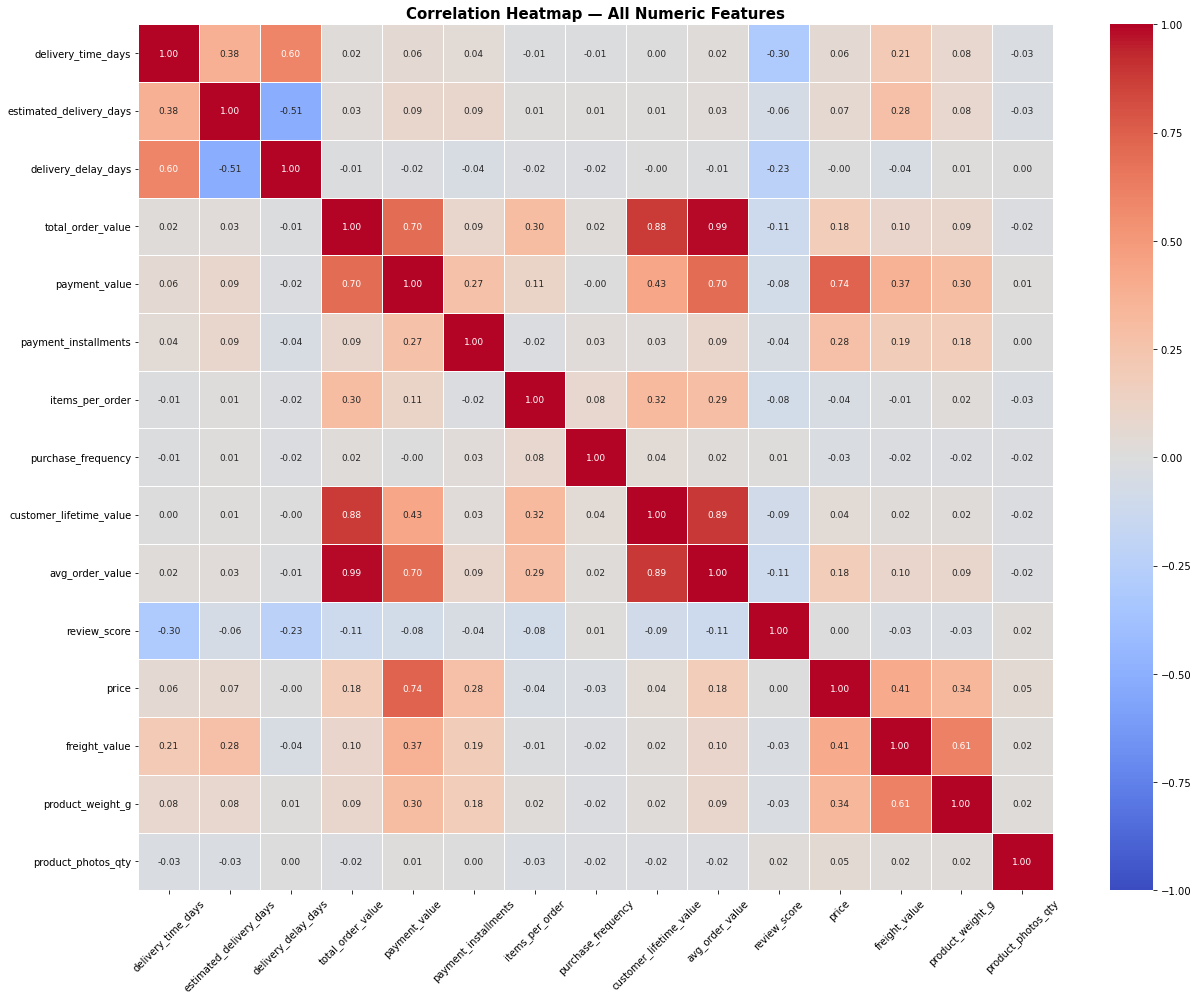

Strongest Correlations:
avg_order_value          total_order_value          0.99
total_order_value        avg_order_value            0.99
customer_lifetime_value  avg_order_value            0.89
avg_order_value          customer_lifetime_value    0.89
total_order_value        customer_lifetime_value    0.88
customer_lifetime_value  total_order_value          0.88
payment_value            price                      0.74
price                    payment_value              0.74
payment_value            total_order_value          0.70
avg_order_value          payment_value              0.70
dtype: float64


In [94]:
# Select all relevant numeric columns
numeric_cols = ["delivery_time_days",
                "estimated_delivery_days",
                "delivery_delay_days",
                "total_order_value",
                "payment_value",
                "payment_installments",
                "items_per_order",
                "purchase_frequency",
                "customer_lifetime_value",
                "avg_order_value",
                "review_score",
                "price",
                "freight_value",
                "product_weight_g",
                "product_photos_qty"]

# Compute correlation matrix
corr_matrix = master[numeric_cols].corr().round(2)

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            linecolor="white",
            ax=ax,
            annot_kws={"size": 9},
            vmin=-1, vmax=1,
            center=0)

ax.set_title("Correlation Heatmap — All Numeric Features",
             fontsize=15, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# Print strongest correlations
print("Strongest Correlations:")
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0]
corr_pairs = corr_pairs.abs().sort_values(ascending=False)
print(corr_pairs.head(10))

Step 7: Business Insights and Recommendations

1.Top Revenue Driving Factors
Factor 1 — Product Category
→ computers_accessories  → R$4.5M  (10.95% of revenue)
→ bed_bath_table         → R$3.8M  (9.41% of revenue)
→ furniture_decor        → R$3.7M  (9.02% of revenue)
→ Top 15 categories      → 80% of total revenue

Factor 2 — Geography
→ SP state alone         → R$28.7M (70% of revenue!)
→ Top 3 states SP+RJ+MG  → 85% of revenue

Factor 3 — Seller Concentration
→ Top 394 sellers        → 80% of revenue
→ Top seller alone       → R$2.1M (5.12%)

Factor 4 — Seasonality
→ November 2017          → R$3.5M (Black Friday peak)
→ Q2 strongest quarter   → 28,626 orders

Factor 5 — Customer Value
→ High value customers   → 40% of customers
→ Generate              → 89% of revenue

2.Highlight customer behavior patterns 
Pattern 1 — One Time Buying
→ 97% customers never returned
→ Only 3% are repeat buyers
→ Average purchase frequency → 1.08 orders

Pattern 2 — Peak Buying Times
→ Monday is busiest day
→ 4PM-5PM is peak hour
→ Q2 (Apr-Jun) is strongest quarter

Pattern 3 — Order Behavior
→ 72% orders have only 1 item
→ Average order value → R$355
→ Median order value  → R$128

Pattern 4 — Payment Behavior
→ Multiple payment methods used
→ Vouchers commonly used for discounts
→ Average installments used for high value orders

Pattern 5 — Geographic Behavior
→ São Paulo city → 14,527 customers (highest)
→ Southeast Brazil dominates customer base
→ Northern states severely underrepresented

3.Evaluate operational inefficiencies 
Inefficiency 1 — Delivery Time
→ Average delivery → 12 days
→ 1 star reviews   → avg 19 days delivery
→ 5 star reviews   → avg 10 days delivery
→ 9 day gap between best and worst experience

Inefficiency 2 — Dead Inventory
→ 59% products have only 1 order ever
→ 19,115 products generating almost no revenue
→ Storage cost with minimal return

Inefficiency 3 — Inactive Sellers
→ 18% sellers have only 1 order (536 sellers)
→ Median seller has only 7 orders
→ Large seller base not being utilized

Inefficiency 4 — Geographic Concentration
→ 70% revenue from SP state only
→ Single state dependency = high risk
→ Logistics disruption in SP = business crisis

Inefficiency 5 — Customer Retention
→ 97% churn rate (never return)
→ Cost of acquiring new customer >>
   cost of retaining existing one
→ No loyalty program evidence in data

Inefficiency 6 — Negative Reviews
→ 12,954 negative reviews (13.41%)
→ Even fast deliveries (0-7 days) 
   getting 2,702 negative reviews
→ Product quality issues not being addressed

4.•	Provide strategic recommendations 
Short Term (0-3 months):
1. Delivery Speed Target
   → Set 10 day delivery as KPI for all orders
   → Alert system for orders crossing 12 days
   → Priority logistics for high value orders
   Evidence → 5 star avg = 10 days delivery

2. Negative Review Response
   → Immediate response team for 1-2 star reviews
   → Root cause analysis for bed_bath_table complaints
   → Product quality audit for top negative categories
   Evidence → 12,954 negative reviews, 1,579 in bed_bath_table

3. Black Friday Preparation
   → November is peak month (R$3.5M, 7,288 orders)
   → Stock up top 15 revenue categories in October
   → Hire extra logistics staff in November
   Evidence → Nov 2017 peak confirmed in data

Medium Term (3-6 months):
4. Customer Retention Program
   → Launch loyalty rewards for repeat customers
   → Personalized discounts for one-time buyers
   → Target high value customers with VIP program
   Evidence → 97% churn rate, 40% drive 89% revenue

5. Seller Development Program
   → Training for bottom 536 inactive sellers
   → Performance incentives for top 394 sellers
   → Recruit sellers in underserved states (BA, GO, DF)
   Evidence → 18% sellers with 1 order only

6. Dead Product Clearance
   → Identify 19,115 single-order products
   → Run clearance campaigns
   → Remove truly dead products from platform
     Evidence → 59% products have only 1 order
   
Long Term (6-12 months):
7. Geographic Expansion
   → Reduce SP dependency (currently 70% revenue)
   → Invest in logistics infrastructure in RJ, MG, PR
   → Marketing campaigns targeting underserved states
   Evidence → SP = 70% revenue, extreme concentration

8. Peak Hour Marketing
   → Schedule promotions at 4PM-5PM daily
   → Monday morning email campaigns
   → Q2 focused marketing budget increase
   Evidence → Peak hour 4PM, Monday highest orders

9. Category Strategy
   → Double down on computers_accessories (highest revenue)
   → Improve quality control in bed_bath_table
   → Explore growth in garden_tools, office_furniture
   Evidence → Category revenue analysis

***Final Summary of my opinion based on analysis***

What's Working:

→ Strong revenue growth (27x in 13 months)
→ 78% positive reviews (4.05 avg score)
→ Clear peak seasons (November, Q2)
→ Strong SP market penetration

What Needs Fixing:

→ 97% customer churn (critical)
→ 12 day avg delivery (target: 10 days)
→ 70% revenue from one state (SP risk)
→ 59% products barely selling

Top 3 Priorities:
1. Customer retention program 2. Delivery speed improvement 3. Geographic expansion beyond SP